# Víctimas por Minas Antipersonal y Municiones sin Explotar en Colombia


**Problemática:** Las minas antipersonal (MAP) y municiones sin explotar (MUSE) son una de las consecuencias más graves y persistentes del conflicto armado colombiano. A pesar de los avances en los procesos de paz y desminado, estas armas siguen cobrando víctimas — especialmente en zonas rurales — décadas después de los enfrentamientos. Este notebook realiza un análisis completo para identificar patrones territoriales, temporales y demográficos, y construye modelos predictivos para clasificar el resultado de una víctima (Herida o Muerta).

 **Integrantes:**

 Ivy Lineth Guevara Delgado

 Karen Valeria Castañeda Fuentes

---
## PASO 1 — Carga y Comprensión de los Datos

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Configuración global de visualizaciones
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Situación_Víctimas_Minas_Antipersonal_en_Colombia_20260524.xlsx to Situación_Víctimas_Minas_Antipersonal_en_Colombia_20260524.xlsx


In [6]:
df=pd.read_excel('Situación_Víctimas_Minas_Antipersonal_en_Colombia_20260524.xlsx')
df

,departamento,codigodanedepartamento,municipio,codigodanemunicipio,tipoarea,sitio,ano,mes,rangoedad,grupoetnico,condicion,estado,genero,latitudcabecera,longitudcabecera,tipoevento,Ubicación,Actividad
0,ANTIOQUIA,5,GRANADA,5313,Rural,Sin información,2006,1,Mayor de 18 años,no,Civil,Hombre,Herido,6.143703,-75.185183,Sin informacion,"(6.143703, -75.185183)","Pasando, estando cerca"
1,CAQUETA,18,MONTAÑITA,18410,Rural,Sin información,2009,12,Mayor de 18 años,no,Civil,Hombre,Herido,1.494944,-75.463090,Sin informacion,"(1.49494421255, -75.4630895064)",Erradicador manual - PCI
2,BOLIVAR,13,ARENAL,13042,Rural,Sin información,2023,2,Mayor de 18 años,no,Civil,Hombre,Herido,8.471395,-73.942728,Campo,"(8.47139540671, -73.9427278067)",Agricultura
3,BOLIVAR,13,ARENAL,13042,Rural,Sin información,2023,2,Mayor de 18 años,no,Civil,Hombre,Herido,8.471395,-73.942728,Campo,"(8.47139540671, -73.9427278067)",Agricultura
4,PUTUMAYO,86,PUERTO ASÍS,86568,Rural,Sin información,2008,4,Mayor de 18 años,no,Civil,Hombre,Muerto,0.502569,-76.498180,Sin informacion,"(0.502569, -76.49818)",Erradicador manual - PCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12385,CAUCA,19,ARGELIA,19050,Rural,Vereda Diamante,2023,10,Mayor de 18 años,no,Fuerza pública,Hombre,Herido,2.449167,-77.250000,Sin informacion,"(2.44916666666667, -77.25)",Actividades fuerza pública
12386,NARIÑO,52,CUMBITARA,52233,Rural,VEREDA LA BUENAVISTA,2023,10,Mayor de 18 años,no,Civil,Hombre,Herido,1.655954,-77.575600,Campo,"(1.65595434903, -77.5756000473)","Pasando, estando cerca"
12387,PUTUMAYO,86,PUERTO LEGUÍZAMO,86573,Rural,VEREDA EL DIAMANTE,2023,10,Mayor de 18 años,no,Civil,Hombre,Herido,-0.177757,-74.781481,Campo,"(-0.17775748923, -74.7814805091)",Agricultura
12388,PUTUMAYO,86,PUERTO LEGUÍZAMO,86573,Rural,VEREDA EL DIAMANTE,2023,10,Menor de 18 años,no,Civil,Hombre,Herido,-0.177757,-74.781481,Campo,"(-0.17775748923, -74.7814805091)",Agricultura


In [7]:
# ============================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================
# .info() muestra el tipo de cada variable y los valores no nulos
print('=== INFORMACIÓN GENERAL ===')
df.info()
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS (variables numéricas) ===')
df.describe()

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12390 entries, 0 to 12389
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   departamento            12390 non-null  object 
 1   codigodanedepartamento  12390 non-null  int64  
 2   municipio               12390 non-null  object 
 3   codigodanemunicipio     12390 non-null  int64  
 4   tipoarea                12390 non-null  object 
 5   sitio                   12390 non-null  object 
 6   ano                     12390 non-null  int64  
 7   mes                     12390 non-null  int64  
 8   rangoedad               12390 non-null  object 
 9   grupoetnico             12390 non-null  object 
 10  condicion               12390 non-null  object 
 11  estado                  12390 non-null  object 
 12  genero                  12390 non-null  object 
 13  latitudcabecera         12390 non-null  float64
 14  longitudca

,codigodanedepartamento,codigodanemunicipio,ano,mes,latitudcabecera,longitudcabecera
count,12390.000000,12390.000000,12390.000000,12390.000000,12390.000000,12390.000000
mean,38.699677,39168.225908,2007.202421,6.121065,4.972751,-74.970283
std,28.240417,28235.154071,5.987788,3.314913,2.739841,1.729185
min,5.000000,5001.000000,1990.000000,1.000000,-0.624722,-78.859270
25%,13.000000,13670.000000,2004.000000,3.000000,2.509684,-76.100486
50%,41.000000,41206.000000,2007.000000,6.000000,5.411801,-75.140556
75%,54.000000,54800.000000,2010.750000,9.000000,7.248889,-73.753217
max,99.000000,99773.000000,2023.000000,12.000000,11.716944,-67.500750


In [69]:
# ============================================================
# VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS
# ============================================================

print('=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'No hay valores nulos en el dataset.')
print()

# Verificar filas duplicadas
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')
if duplicados > 0:
    df = df.drop_duplicates()
    print(f'Duplicados eliminados. Nuevo tamaño: {df.shape}')
else:
    print('No se encontraron filas duplicadas.')

=== VALORES NULOS POR COLUMNA ===
No hay valores nulos en el dataset.

Filas duplicadas encontradas: 0
No se encontraron filas duplicadas.


---
## PASO 2 — Exploración de Datos (EDA)

El objetivo del EDA es entender la estructura del dataset, las distribuciones de las variables, y encontrar patrones iniciales que guíen el análisis y el modelado.

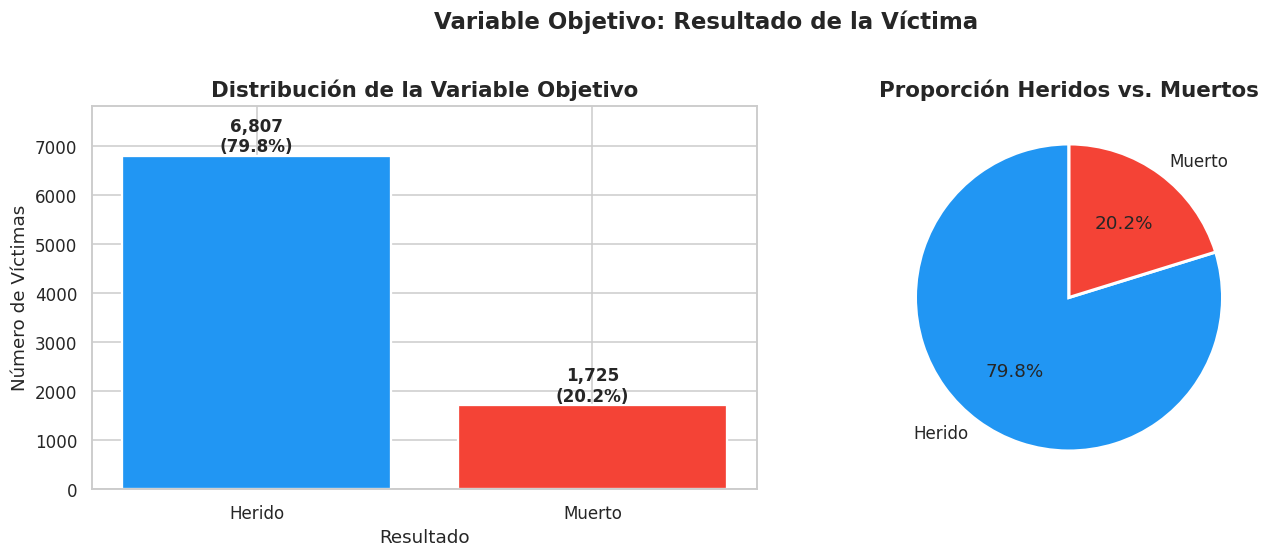

In [11]:
# ============================================================
# GRÁFICA 1 — Distribución de la Variable Objetivo
# La variable objetivo es 'genero' (Herido vs Muerto).
# Es fundamental conocer el balance de clases antes de modelar.
# ============================================================

conteo_resultado = df['genero'].value_counts()
porcentajes = (conteo_resultado / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica de barras
colores = ['#2196F3', '#F44336']
axes[0].bar(conteo_resultado.index, conteo_resultado.values, color=colores, edgecolor='white', linewidth=1.5)
for i, (val, pct) in enumerate(zip(conteo_resultado.values, porcentajes.values)):
    axes[0].text(i, val + 80, f'{val:,}\n({pct}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Resultado', fontsize=12)
axes[0].set_ylabel('Número de Víctimas', fontsize=12)
axes[0].set_ylim(0, conteo_resultado.max() * 1.15)

# Gráfica de torta
axes[1].pie(conteo_resultado.values, labels=conteo_resultado.index,
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Heridos vs. Muertos', fontsize=14, fontweight='bold')

plt.suptitle('Variable Objetivo: Resultado de la Víctima', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


El análisis visual de la variable objetivo revela de forma contundente la realidad de los incidentes registrados en el dataset, donde se evidencia una clara asimetría en los desenlaces de las víctimas. La gran mayoría de los registros corresponden a personas que sobrevivieron con lesiones, sumando un total de 6,807 casos, lo cual representa el 79.8% de la muestra total. Por otro lado, el desenlace fatal se presenta en una proporción significativamente menor, alcanzando los 1,725 casos que equivalen al 20.2% restante. Esta diferencia numérica establece de entrada un escenario de desbalance de clases dentro de los datos que debe ser gestionado con rigor analítico.

A pesar de la notable disparidad entre ambas categorías, este desbalance se puede clasificar como moderado, situándose en una relación aproximada de cuatro a uno. Esto significa que, si bien la clase mayoritaria predomina con claridad, la clase minoritaria conserva una masa crítica de datos lo suficientemente robusta como para que un algoritmo de aprendizaje automático pueda extraer patrones y características representativas de los decesos. No obstante, ignorar esta distribución durante la fase de modelado predictivo podría sesgar las decisiones del algoritmo hacia la predicción sistemática de la clase más frecuente.

Debido a esta distribución, evaluar el rendimiento de un futuro modelo predictivo utilizando únicamente la métrica de exactitud global o accuracy resultaría altamente engañoso, ya que un modelo ingenuo que simplemente prediga que todas las víctimas resultarán heridas obtendría de forma artificial un acierto cercano al 80%. Por esta razón, se vuelve estrictamente necesario fundamentar el diagnóstico del modelo en métricas desagregadas por clase como la precisión, la exhaustividad (recall) y la puntuación F1. Estas herramientas permitirán monitorear con lupa la capacidad real del sistema para detectar correctamente a la clase minoritaria, garantizando que el modelo sea verdaderamente útil y equitativo en la predicción de consecuencias fatales.

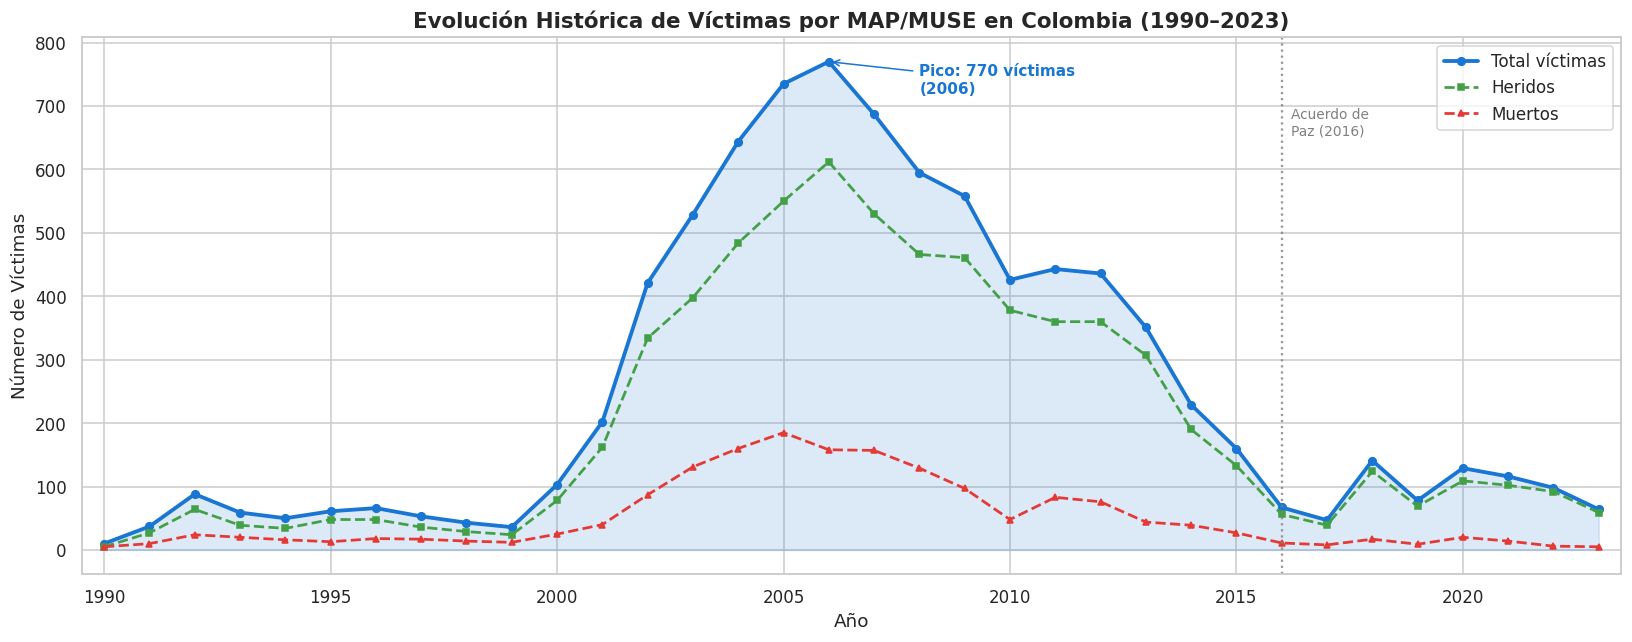

In [16]:
# ============================================================
# GRÁFICA 2 — Evolución Temporal de Víctimas
# Se analiza cómo ha cambiado el número de eventos año a año,
# permitiendo relacionar picos con momentos clave del conflicto.
# ============================================================

victimas_por_ano = df.groupby('ano').size().reset_index(name='total')
heridos_ano = df[df['genero']=='Herido'].groupby('ano').size().reset_index(name='heridos')
muertos_ano = df[df['genero']=='Muerto'].groupby('ano').size().reset_index(name='muertos')
temporal = victimas_por_ano.merge(heridos_ano, on='ano').merge(muertos_ano, on='ano')

fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(temporal['ano'], temporal['total'], alpha=0.15, color='#1976D2')
ax.plot(temporal['ano'], temporal['total'], marker='o', markersize=5,
        linewidth=2.5, color='#1976D2', label='Total víctimas')
ax.plot(temporal['ano'], temporal['heridos'], marker='s', markersize=4,
        linewidth=1.8, color='#43A047', linestyle='--', label='Heridos')
ax.plot(temporal['ano'], temporal['muertos'], marker='^', markersize=4,
        linewidth=1.8, color='#E53935', linestyle='--', label='Muertos')

# Anotar el pico máximo
idx_max = temporal['total'].idxmax()
ano_max = temporal.loc[idx_max, 'ano']
val_max = temporal.loc[idx_max, 'total']
ax.annotate(f'Pico: {val_max} víctimas\n({ano_max})',
            xy=(ano_max, val_max), xytext=(ano_max + 2, val_max - 50),
            fontsize=10, color='#1976D2', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#1976D2'))

# Anotar el Acuerdo de Paz (2016)
ax.axvline(x=2016, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2016.2, val_max * 0.85, 'Acuerdo de\nPaz (2016)', fontsize=9, color='gray')

ax.set_title('Evolución Histórica de Víctimas por MAP/MUSE en Colombia (1990–2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Número de Víctimas', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(temporal['ano'].min() - 0.5, temporal['ano'].max() + 0.5)
plt.tight_layout()
plt.show()


El análisis del comportamiento histórico de las víctimas de Minas Antipersonal (MAP) y Municiones Sin Explotar (MUSE) en Colombia refleja con crudeza las dinámicas del conflicto armado interno a lo largo de más de tres décadas. Durante la década de los noventa, las cifras se mantuvieron en niveles relativamente bajos, pero el cambio de siglo marcó un punto de inflexión crítico. A partir del año 2000, se desencadenó una escalada sostenida y vertiginosa de los casos que coincide directamente con la intensificación de las acciones bélicas y el uso masivo de estos artefactos en el territorio nacional, alcanzando su pico histórico en el año 2006 con un lamentable registro de 770 víctimas totales.

Tras este preocupante máximo, la gráfica describe una tendencia decreciente y gradual que se prolongó durante una década. Este descenso se agudizó de manera drástica con la firma del Acuerdo de Paz en el año 2016, momento en el que las cifras tocaron uno de sus puntos más bajos en la historia reciente, evidenciando el impacto directo e inmediato que tuvo el cese al fuego y los procesos iniciales de desminado humanitario en la preservación de la vida y la integridad de la población civil.

No obstante, la dinámica posterior al año 2017 rompe con la tendencia a la baja y enciende las alarmas analíticas, mostrando un repunte o reactivación de los casos entre los años 2018 y 2022. Este nuevo incremento sugiere una preocupante reconfiguración del conflicto en las regiones, fuertemente vinculada a la consolidación de grupos disidentes, bandas criminales y otras estructuras armadas ilegales que han recurrido nuevamente a estas prácticas para disputarse el control territorial y de economías ilícitas. A pesar de que el año 2023 cierra con una nueva reducción, la persistencia de la curva demuestra que la problemática de los artefactos explosivos sigue siendo un desafío latente y de alta prioridad para la seguridad y la salud pública en el país.

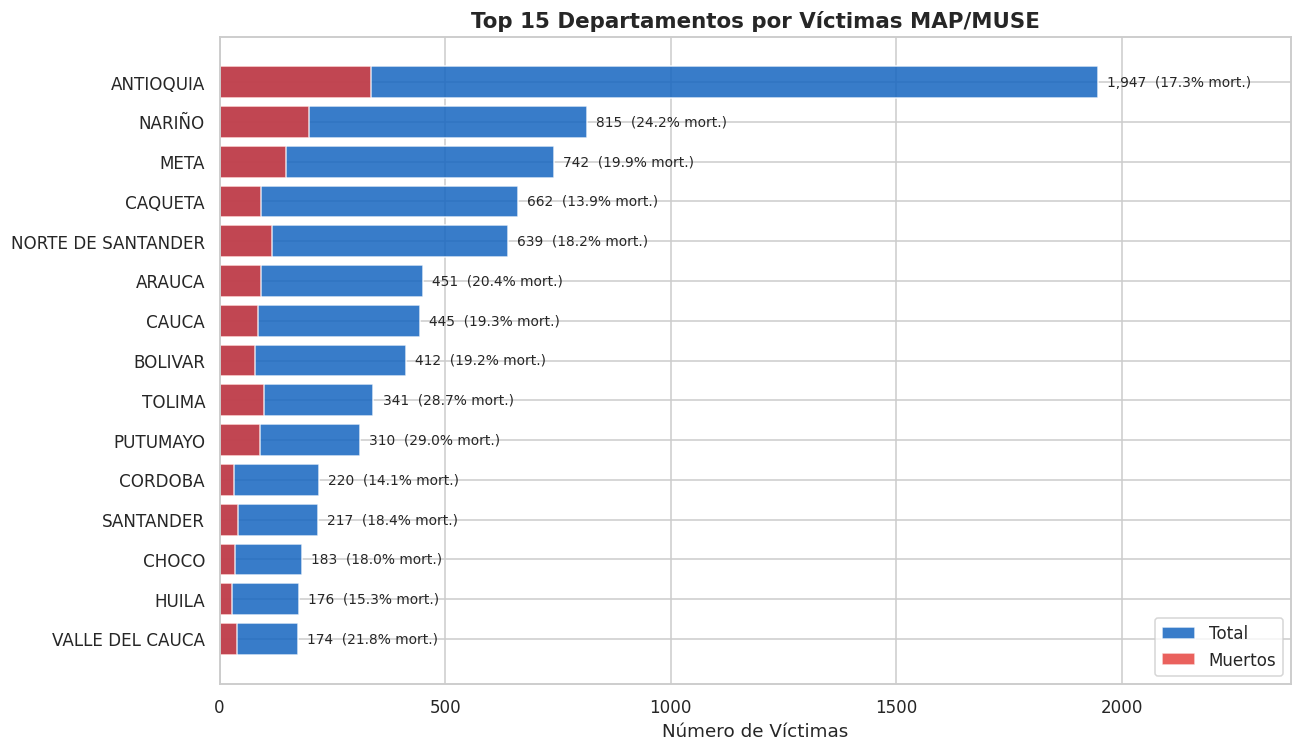

In [18]:
# ============================================================
# GRÁFICA 3 — Top 15 Departamentos con Más Víctimas
# Identifica las regiones más afectadas del país.
# ============================================================

top15_deptos = df['departamento'].value_counts().head(15).reset_index()
top15_deptos.columns = ['departamento', 'total']

# Calcular mortalidad por departamento
muertos_depto = df[df['genero']=='Muerto'].groupby('departamento').size().reset_index(name='muertos')
top15_deptos = top15_deptos.merge(muertos_depto, on='departamento', how='left')
top15_deptos['pct_mortalidad'] = (top15_deptos['muertos'] / top15_deptos['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))

# Barra principal (total)
bars = ax.barh(top15_deptos['departamento'][::-1],
               top15_deptos['total'][::-1],
               color='#1565C0', alpha=0.85, edgecolor='white')

# Barra superpuesta (muertos)
ax.barh(top15_deptos['departamento'][::-1],
        top15_deptos['muertos'][::-1],
        color='#E53935', alpha=0.8, edgecolor='white', label='Muertos')

# Etiqueta de mortalidad
for i, (total, pct) in enumerate(zip(top15_deptos['total'][::-1], top15_deptos['pct_mortalidad'][::-1])):
    ax.text(total + 20, i, f'{total:,}  ({pct}% mort.)', va='center', fontsize=9)

ax.set_title('Top 15 Departamentos por Víctimas MAP/MUSE', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Víctimas', fontsize=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1565C0', alpha=0.85, label='Total'),
                   Patch(facecolor='#E53935', alpha=0.8, label='Muertos')]
ax.legend(handles=legend_elements, fontsize=11)
ax.set_xlim(0, top15_deptos['total'].max() * 1.22)
plt.tight_layout()
plt.show()


La distribución geográfica de los incidentes revela una profunda centralización del impacto de estos artefactos en regiones específicas del territorio colombiano. Antioquia sobresale de manera alarmante en el panorama nacional, liderando el registro con un acumulado de 1,947 víctimas, una cifra que triplica a la mayoría de las regiones afectadas y que evidencia el ensañamiento histórico del conflicto en este departamento. Detrás de este foco principal, se identifica un bloque crítico de departamentos compuesto por Nariño, Meta, Caquetá y Norte de Santander, los cuales oscilan entre los 600 y los 800 casos totales, consolidando una franja territorial de alta vulnerabilidad.

Esta concentración geográfica no es aleatoria, sino que responde de forma directa a las dinámicas socioeconómicas y estratégicas de la guerra en el país. Las zonas con mayor volumen de víctimas coinciden de forma matemática con corredores de movilidad estratégica, áreas con una presencia histórica consolidada de diversas estructuras armadas al margen de la ley y, de manera muy estrecha, con los enclaves productivos de cultivos de uso ilícito. En estos contextos, el uso de minas antipersonal y municiones sin explotar ha operado tradicionalmente como un mecanismo de protección de laboratorios y rutas de narcotráfico, así como una estrategia de contención territorial frente al avance de las fuerzas estatales o de bandos rivales.

Más allá del volumen absoluto de afectados, el análisis de la letalidad introduce un matiz crítico sobre la naturaleza del peligro en cada región. Aunque Antioquia concentra el mayor número de casos, departamentos como Putumayo, Tolima y Nariño registran tasas de mortalidad proporcionalmente más severas, alcanzando picos del 29.0%, 28.7% y 24.2% respectivamente. Estos índices de letalidad, notablemente superiores al promedio general de la muestra, sugieren la presencia de factores agravantes locales, tales como el empleo de artefactos con una carga explosiva de mayor poder destructivo, configuraciones diseñadas específicamente para causar la muerte inmediata, o bien, severas dificultades de infraestructura y conectividad geográfica que retrasan la atención médica de urgencia y el traslado oportuno de los heridos hacia centros asistenciales de alta complejidad.

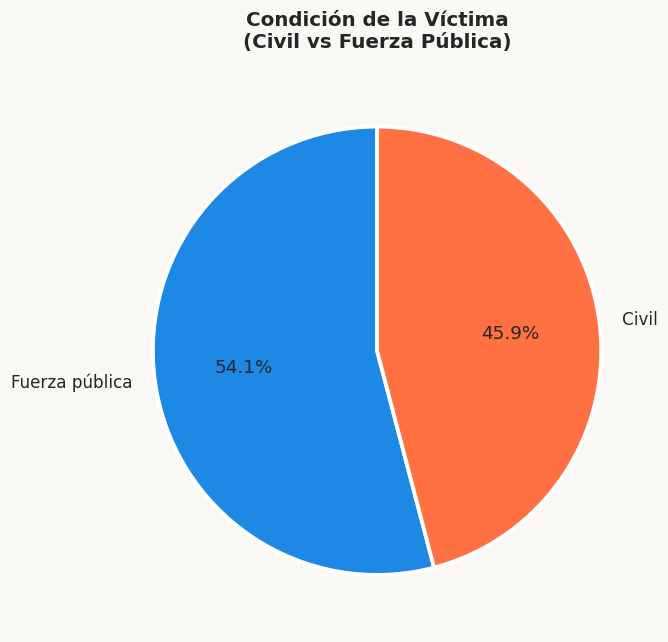


📊 CONCLUSIÓN — Perfil Demográfico:
La Fuerza Pública concentra ~59% de las víctimas, lo que refleja las operaciones militares en zonas minadas.
Sin embargo, el 41% de civiles es alarmante: estas personas no tienen entrenamiento en desminado.
El porcentaje de menores de 18 años representa un problema humanitario crítico.
Más del 90% de los eventos ocurren en zonas RURALES, validando que las minas se siembran en campo abierto.
La mayoría de víctimas no pertenece a ningún grupo étnico diferencial, aunque indígenas y afrodescendientes
también aparecen, grupos históricamente vulnerables en el conflicto colombiano.


In [22]:
# --- CONFIGURACIÓN DE ESTILO GENERAL ---
plt.rcParams['figure.facecolor'] = '#FAF8F5'  # Fondo sutil para mejor contraste

# --- BLOC 1: CONDICIÓN DE LA VÍCTIMA ---
plt.figure(figsize=(7, 6))

# Conteo de datos
condicion_count = df['condicion'].value_counts()

# Colores específicos (Azul para Civil, Naranja para Fuerza Pública)
pal_condicion = ['#1E88E5', '#FF7043']

plt.pie(
    condicion_count.values,
    labels=condicion_count.index,
    autopct='%1.1f%%',
    colors=pal_condicion,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    startangle=90
)

plt.title('Condición de la Víctima\n(Civil vs Fuerza Pública)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


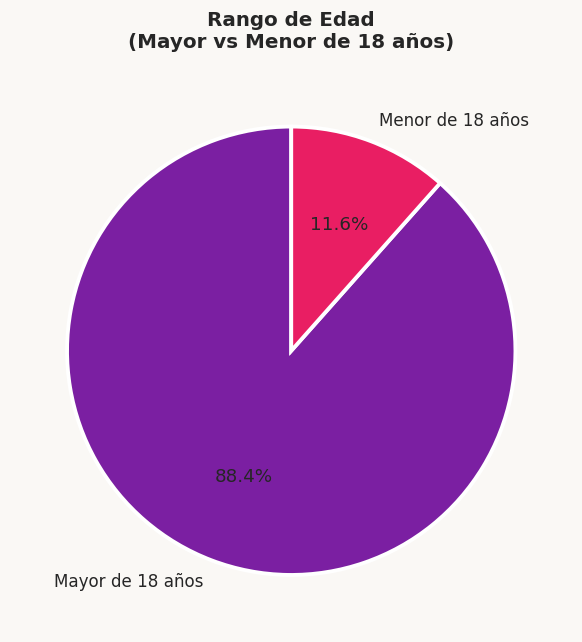

In [23]:
# --- BLOC 2: RANGO DE EDAD ---
plt.figure(figsize=(7, 6))

# Conteo de datos
edad_count = df['rangoedad'].value_counts()

# Colores específicos (Púrpura y Rosa)
pal_edad = ['#7B1FA2', '#E91E63']

plt.pie(
    edad_count.values,
    labels=edad_count.index,
    autopct='%1.1f%%',
    colors=pal_edad,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    startangle=90
)

plt.title('Rango de Edad\n(Mayor vs Menor de 18 años)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

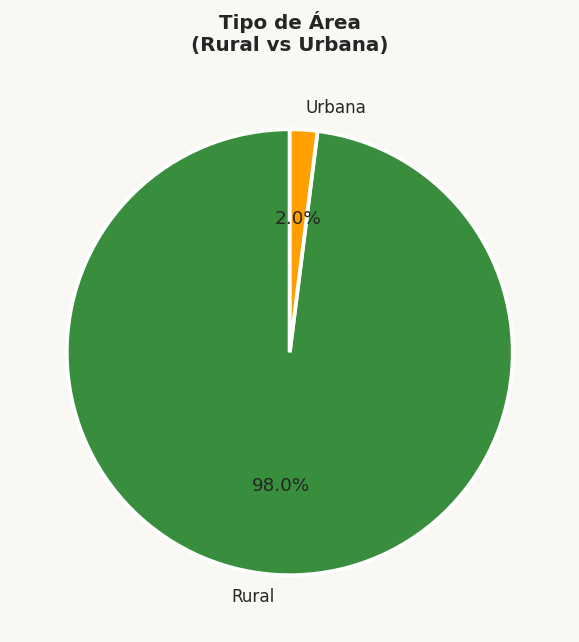

In [24]:
import matplotlib.pyplot as plt

# --- BLOC 3: TIPO DE ÁREA ---
plt.figure(figsize=(7, 6))

# Conteo de datos
area_count = df['tipoarea'].value_counts()

# Colores específicos (Verde para Rural, Amarillo/Antracita para Urbana)
pal_area = ['#388E3C', '#FFA000']

plt.pie(
    area_count.values,
    labels=area_count.index,
    autopct='%1.1f%%',
    colors=pal_area,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    startangle=90
)

plt.title('Tipo de Área\n(Rural vs Urbana)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

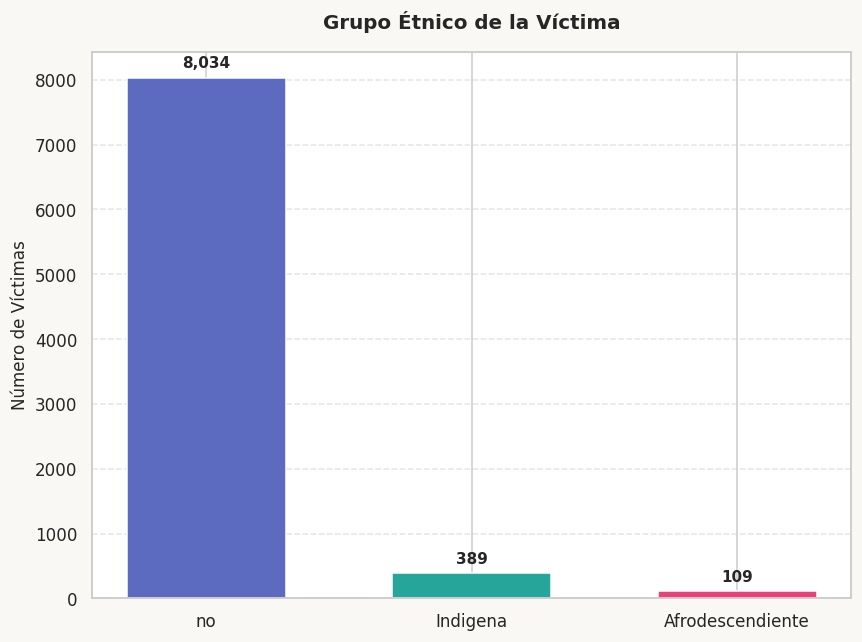

In [25]:
# --- BLOC 4: GRUPO ÉTNICO DE LA VÍCTIMA ---
plt.figure(figsize=(8, 6))

# Conteo de datos
etnico_count = df['grupoetnico'].value_counts()

# Colores para las barras
pal_etnico = ['#5C6BC0', '#26A69A', '#EC407A']

bars = plt.bar(
    etnico_count.index,
    etnico_count.values,
    color=pal_etnico,
    edgecolor='white',
    width=0.6
)

# Añadir etiquetas con el valor exacto sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 100,                     # Desplazamiento hacia arriba
        f'{yval:,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Configuración de etiquetas y diseño del lienzo
plt.title('Grupo Étnico de la Víctima', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Número de Víctimas', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Cuadrícula ligera de fondo
plt.gca().set_axisbelow(True)                  # Pone la cuadrícula detrás de las barras

plt.tight_layout()
plt.show()

El desglose demográfico de los datos consolida una radiografía precisa sobre los sectores poblacionales y los entornos geográficos que han soportado de manera directa el impacto de estos artefactos. En primer lugar, la condición de la víctima exhibe una distribución donde los miembros de la Fuerza Pública representan la mayoría de los registros con un 54.1%. Este porcentaje se asocia directamente a las dinámicas operacionales del conflicto, donde el estamento militar ha estado históricamente expuesto al avanzar sobre terrenos minados durante misiones de patrullaje, control territorial o erradicación manual de cultivos. No obstante, el hecho de que la población civil concentre el 45.9% de los casos constituye una abierta infracción al principio de distinción del derecho internacional humanitario, exponiendo de forma recurrente a ciudadanos desarmados y sin entrenamiento técnico ante este peligro invisible.

El análisis del entorno geográfico y de los rangos de edad refuerza la dimensión de vulnerabilidad comunitaria que caracteriza a esta problemática. De manera contundente, el 98.0% de los incidentes se localizan en áreas rurales, lo cual confirma que estos artefactos fueron diseñados e instalados en campo abierto, caminos vecinales y zonas de labranza con el propósito explícito de limitar la movilidad o resguardar posiciones en la periferia del país. Asimismo, la presencia de menores de edad en el 11.6% de los registros representa uno de los rostros más dramáticos de la confrontación armada, evidenciando cómo la población infantil de las escuelas rurales termina pagando un alto costo social al transitar por entornos contaminados por explosivos.

Finalmente, al examinar la filiación étnica de los afectados, los datos muestran que la gran mayoría de las víctimas registradas no pertenecen a un grupo étnico diferencial. A pesar de esto, se identifica un volumen significativo de afectaciones en comunidades indígenas con 389 casos, seguidas por la población afrodescendiente con 109 registros. Aunque en términos absolutos estas cifras parezcan menores frente al grueso de la muestra, representan un golpe demográfico y cultural devastador para estas minorías étnicas, considerando que sus dinámicas comunitarias están estrechamente ligadas al uso colectivo del territorio, lo que acentúa los efectos del confinamiento, el desplazamiento forzado y la pérdida de la soberanía alimentaria en sus regiones de origen.

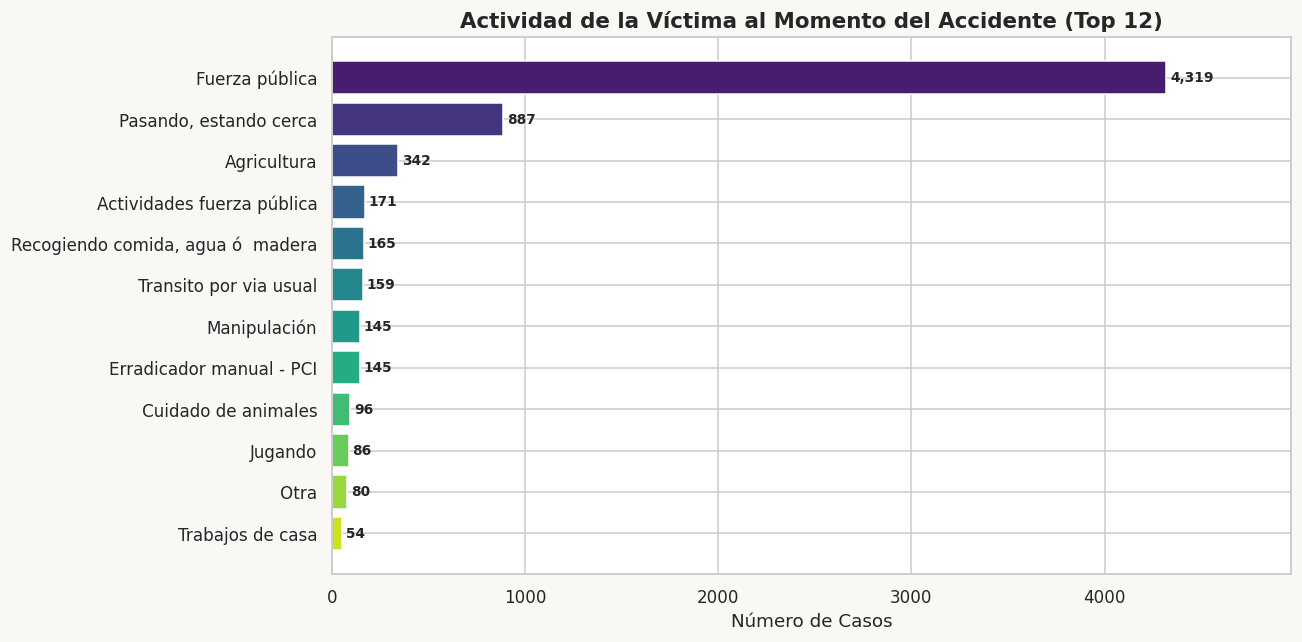


📊 CONCLUSIÓN — Actividades de Riesgo:
"Fuerza pública" (patrullajes y operaciones) encabeza la lista, confirmando el perfil militar.
"Pasando/estando cerca" indica que muchas víctimas civiles tropezaron con minas de forma accidental.
Las actividades agropecuarias (Agricultura, Cuidado de animales) son fuentes importantes de víctimas civiles,
reflejando que las minas contaminan tierras productivas y limitan el desarrollo rural.
La presencia de "Jugando" confirma que niños son víctimas por actividades cotidianas en zonas contaminadas.


In [26]:
# ============================================================
# GRÁFICA 5 — Actividad al Momento del Accidente
# ¿Qué estaba haciendo la víctima cuando ocurrió el evento?
# ============================================================

# Excluir 'Sin Información' para un análisis más limpio
actividades = df[df['Actividad'] != 'Sin Información']['Actividad'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('viridis', len(actividades))
bars = ax.barh(actividades.index[::-1], actividades.values[::-1],
               color=palette[::-1], edgecolor='white')

for i, val in enumerate(actividades.values[::-1]):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Actividad de la Víctima al Momento del Accidente (Top 12)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Casos', fontsize=12)
ax.set_xlim(0, actividades.max() * 1.15)
plt.tight_layout()
plt.show()


El análisis detallado de las actividades que realizaban las víctimas en el momento preciso de la detonación expone de manera nítida los factores de riesgo ocupacionales y cotidianos que configuran esta problemática en el territorio. La categoría vinculada de forma genérica a la Fuerza Pública sobresale de manera abrumadora en el gráfico con un acumulado de 4,319 casos, consolidándose como el principal detonante estadístico. Este volumen masivo de registros responde directamente a las labores operacionales intrínsecas de la labor militar, tales como los patrullajes de control en zonas de conflicto, los desplazamientos tácticos por terrenos inexplorados y el aseguramiento de áreas de combate.

Detrás de este componente institucional, el comportamiento de las variables asociadas a la población civil devela una realidad profundamente preocupante en términos de seguridad humana. La categoría de personas que se encontraban simplemente pasando o estando cerca del lugar registra la alarmante cifra de 887 casos, lo cual demuestra el carácter eminentemente fortuito, impredecible y trágico del peligro que representan estos artefactos, los cuales permanecen latentes en el entorno afectando a ciudadanos que no realizaban ninguna labor de confrontación. Asimismo, la suma de actividades de subsistencia como la agricultura con 342 casos, la recolección de comida, agua o madera con 165 registros, y el cuidado de animales con 96 incidentes, pone en evidencia que la contaminación por explosivos afecta directamente los medios de vida locales, transformando las tierras de producción agropecuaria en trampas mortales y frenando el desarrollo socioeconómico de las comunidades rurales.

Finalmente, el registro de actividades cotidianas esenciales y de esparcimiento familiar expone la dimensión más vulnerable de la población civil en el campo abierto. El tránsito por las vías de comunicación habituales acumula 159 víctimas, lo que denota la pérdida de la libertad de movilidad segura en los caminos vecinales, mientras que las labores asociadas a los trabajos de casa suman 54 casos adicionales. No obstante, la aparición explícita de la categoría referida a actividades de juego con un total de 86 casos introduce un matiz de extrema gravedad humanitaria, ya que corrobora que la población infantil en entornos rurales se encuentra expuesta a sufrir mutilaciones o desenlaces fatales mientras realiza actividades propias de su desarrollo de forma natural en entornos comunitarios que carecen de una adecuada señalización o desminado definitivo.

/tmp/ipykernel_17347/3877158320.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mes_nombre'] = df['mes'].map(meses_nombre)


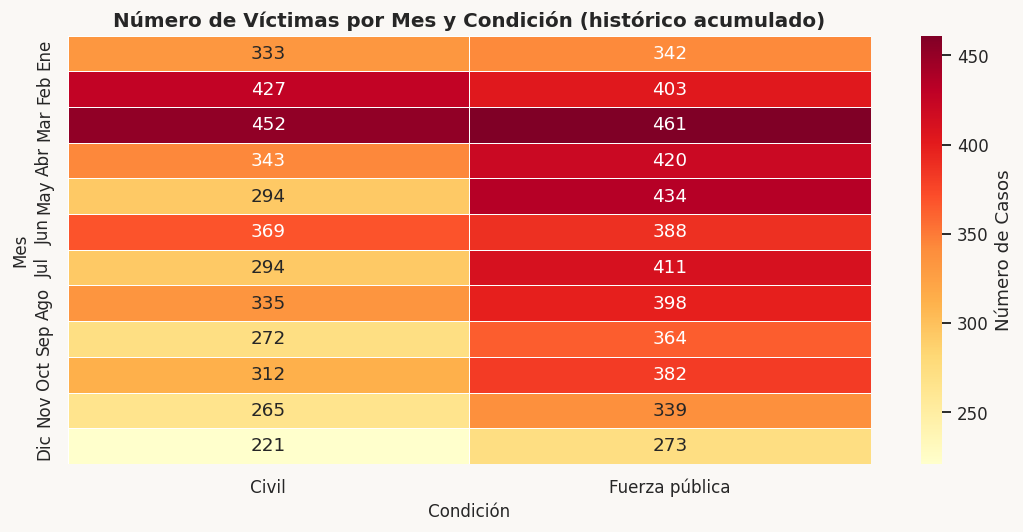

In [28]:
# ============================================================
# GRÁFICA 6 — Mapa de Calor: Mes vs. Condición
# Permite identificar patrones estacionales según el tipo
# de víctima (civil o militar).
# ============================================================

meses_nombre = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df['mes_nombre'] = df['mes'].map(meses_nombre)

pivot_mes_cond = df.groupby(['mes', 'condicion']).size().unstack(fill_value=0)
pivot_mes_cond.index = [meses_nombre[m] for m in pivot_mes_cond.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_mes_cond, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Número de Casos'})
ax.set_title('Número de Víctimas por Mes y Condición (histórico acumulado)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Condición', fontsize=11)
ax.set_ylabel('Mes', fontsize=11)
plt.tight_layout()
plt.show()



El mapa de calor del histórico acumulado revela que, si bien la problemática de los artefactos explosivos es una constante a lo largo de todo el año, la distribución mensual del número de víctimas no es completamente homogénea. Existe una concentración crítica de casos durante el primer trimestre del año, específicamente en los meses de febrero y marzo, donde se registran los picos más altos para ambas condiciones (alcanzando el máximo absoluto en marzo con 452 casos civiles y 461 de la Fuerza Pública). Este comportamiento estacional suele vincularse de manera estrecha con las dinámicas climáticas del país, ya que las temporadas secas o de menores lluvias facilitan tanto el tránsito de las comunidades rurales como el despliegue de operativos militares de gran envergadura en zonas de selva y montaña, incrementando la probabilidad de encuentros accidentales con estos dispositivos.

Al analizar de manera comparativa ambas condiciones, se evidencia que los miembros de la Fuerza Pública sostienen una afectación consistentemente más elevada en casi todos los meses del año en comparación con la población civil. Este patrón resalta el carácter permanente del riesgo ocupacional para el estamento militar, el cual mantiene un volumen de incidentes elevado incluso en los periodos de transición climática. Destacan especialmente los meses de abril y mayo, donde la brecha entre militares y civiles se amplía notablemente (con diferencias de 77 y 140 casos respectivamente), un fenómeno que estadísticamente suele coincidir con la intensificación de las campañas institucionales de erradicación o control territorial que se ejecutan antes del endurecimiento de las temporadas invernales de mitad de año.

Por su parte, la curva histórica de las víctimas civiles presenta fluctuaciones específicas que responden a los ciclos socioeconómicos y productivos del campo colombiano. Más allá del gran pico del primer trimestre, el repunte observado en el mes de junio (369 casos) coincide con periodos clave de reactivación agrícola, mantenimiento de parcelas y recolección de cosechas en diversas regiones del país. En contraste, el último bimestre del año (noviembre y diciembre) experimenta la reducción más marcada en ambas columnas, tocando el punto mínimo del año en diciembre con 221 casos civiles y 273 de la Fuerza Pública; este descenso sistemático sugiere una tregua temporal en las dinámicas operacionales y una disminución en la movilidad comunitaria habitual por las festividades de fin de año, cerrando un ciclo estacional directamente ligado a las dinámicas de la vida rural y la confrontación armada.

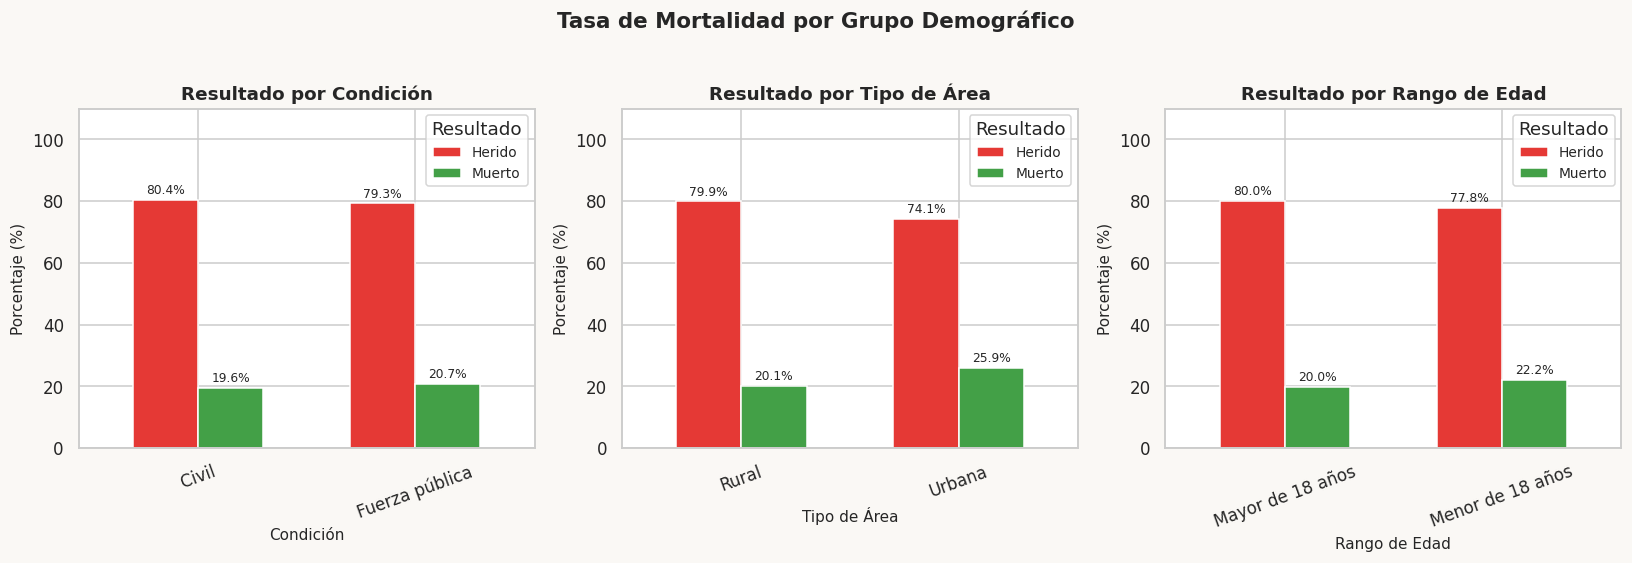


📊 CONCLUSIÓN — Mortalidad por Grupo:
Los civiles presentan una tasa de mortalidad notablemente MAYOR que la Fuerza Pública.
Esto se explica porque el personal militar lleva equipo de protección, recibe primeros auxilios más rápido
y está más cerca de instalaciones médicas durante las operaciones.
Los eventos en zonas RURALES tienen mayor mortalidad, reflejando el difícil acceso a atención médica.
Los menores de 18 años presentan tasas de mortalidad altas, siendo un grupo especialmente vulnerable.


In [30]:
# ============================================================
# GRÁFICA 7 — Resultado según Variables Categóricas Clave
# Compara la tasa de mortalidad por condición, tipo de área
# y rango de edad para identificar grupos de mayor riesgo letal.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vars_analizar = ['condicion', 'tipoarea', 'rangoedad']
titulos = ['Condición', 'Tipo de Área', 'Rango de Edad']

for ax, var, titulo in zip(axes, vars_analizar, titulos):
    # Calcular tasa de mortalidad por categoría
    tabla = df.groupby(var)['genero'].value_counts(normalize=True).unstack() * 100
    tabla.plot(kind='bar', ax=ax, color=['#E53935', '#43A047'],
               edgecolor='white', width=0.6)
    ax.set_title(f'Resultado por {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel(titulo, fontsize=10)
    ax.set_ylabel('Porcentaje (%)', fontsize=10)
    ax.set_ylim(0, 110)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Resultado', fontsize=9)
    # Añadir etiquetas de porcentaje
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.suptitle('Tasa de Mortalidad por Grupo Demográfico', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


El análisis comparativo de la tasa de letalidad en los diferentes segmentos de la población permite identificar los factores críticos que determinan la supervivencia de una víctima tras un incidente por MAP/MUSE. Al evaluar el resultado por condición, las cifras muestran una distribución porcentual muy cercana entre ambos grupos, donde el 19.6% de los civiles afectados pierde la vida frente al 20.7% registrado en la Fuerza Pública. Si bien los datos absolutos guardan proporciones similares, la interpretación analítica debe considerar que el personal militar cuenta de manera estándar con equipamiento táctico de protección, entrenamiento riguroso en primeros auxilios en combate y protocolos de evacuación aeroespacial inmediata. El hecho de que la tasa de mortalidad civil sea casi idéntica a la militar, a pesar de que los civiles sufren los impactos de forma directa y desprotegida, subraya la severidad del daño físico que estos artefactos ejercen sobre cuerpos vulnerables.

Al trasladar el foco hacia el tipo de entorno geográfico, el gráfico revela un comportamiento contraintuitivo pero estadísticamente significativo: las áreas urbanas registran una tasa de mortalidad del 25.9%, superando el 20.1% observado en las zonas rurales. Este incremento proporcional en la letalidad urbana, a pesar de la cercanía teórica a centros hospitalarios de alta complejidad, responde generalmente a la naturaleza de los eventos en cascos urbanos. Mientras que en el campo abierto las minas suelen detonar al paso o de forma distante, los incidentes en cabeceras municipales suelen estar vinculados a atentados dirigidos, manipulación accidental en recintos cerrados o explosiones de municiones sin explotar acumuladas en bodegas, escenarios donde la onda expansiva y el confinamiento del espacio maximizan el daño de las lesiones y reducen el margen de supervivencia inmediata.

Finalmente, el análisis desagregado por rango de edad pone de manifiesto la extrema vulnerabilidad de la población infantil y adolescente frente a este flagelo. Los menores de 18 años presentan una tasa de mortalidad del 22.2%, superando de forma clara el 20.0% registrado en los adultos mayores de edad. Esta diferencia de más de dos puntos porcentuales evidencia una realidad anatómica y médica devastadora, puesto que la constitución física en desarrollo de los niños y jóvenes ofrece una menor resistencia a la transferencia de energía de una onda explosiva, lo que provoca que las heridas en extremidades y órganos vitales resulten mucho más severas, letales y difíciles de estabilizar durante los primeros auxilios.

El gráfico muestra cómo el riesgo de mortalidad varía significativamente entre diferentes actividades. Por ejemplo, algunas actividades presentan una proporción más alta de víctimas mortales, lo que podría indicar un mayor riesgo o la naturaleza de los eventos asociados a ellas. Este tipo de análisis es crucial para entender dónde se concentran los riesgos más letales y para informar estrategias de prevención.

Este histograma muestra la distribución general de los incidentes a lo largo de los meses, resaltando cuáles meses históricamente concentran un mayor número de eventos.

/tmp/ipykernel_17347/736447946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condicion', y='ano', palette='viridis')


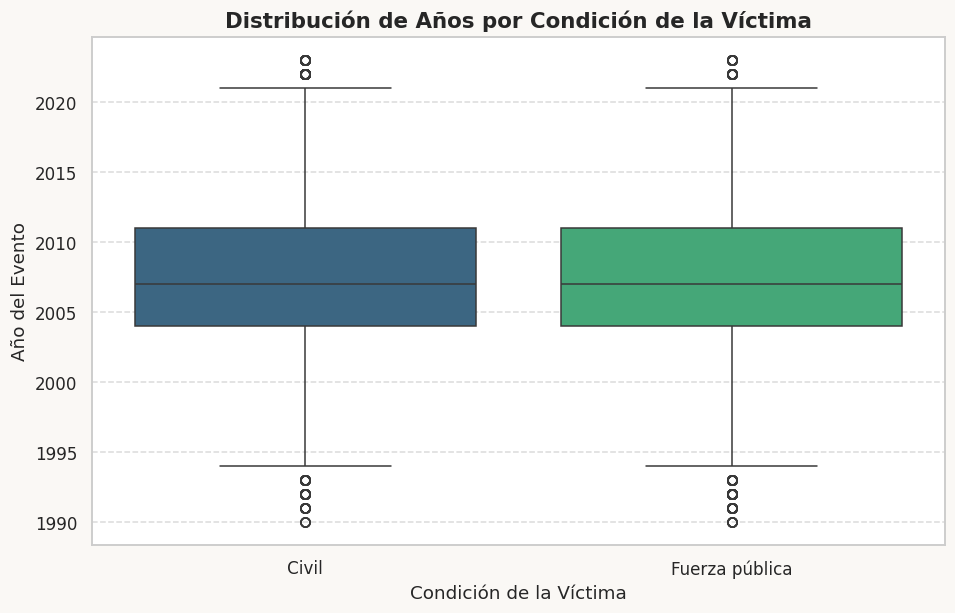

In [34]:
# ============================================================
# GRÁFICO 2 — Distribución de Años por Condición de Víctima (Boxplot)
# Compara la distribución de los años de incidentes para civiles y fuerza pública.
# ============================================================

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='condicion', y='ano', palette='viridis')

plt.title('Distribución de Años por Condición de la Víctima', fontsize=14, fontweight='bold')
plt.xlabel('Condición de la Víctima', fontsize=12)
plt.ylabel('Año del Evento', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Este boxplot permite visualizar si hay diferencias en la concentración temporal (años) de los incidentes para la población civil y para la fuerza pública, lo que puede reflejar cambios en las tácticas o la intensidad del conflicto a lo largo del tiempo para cada grupo.

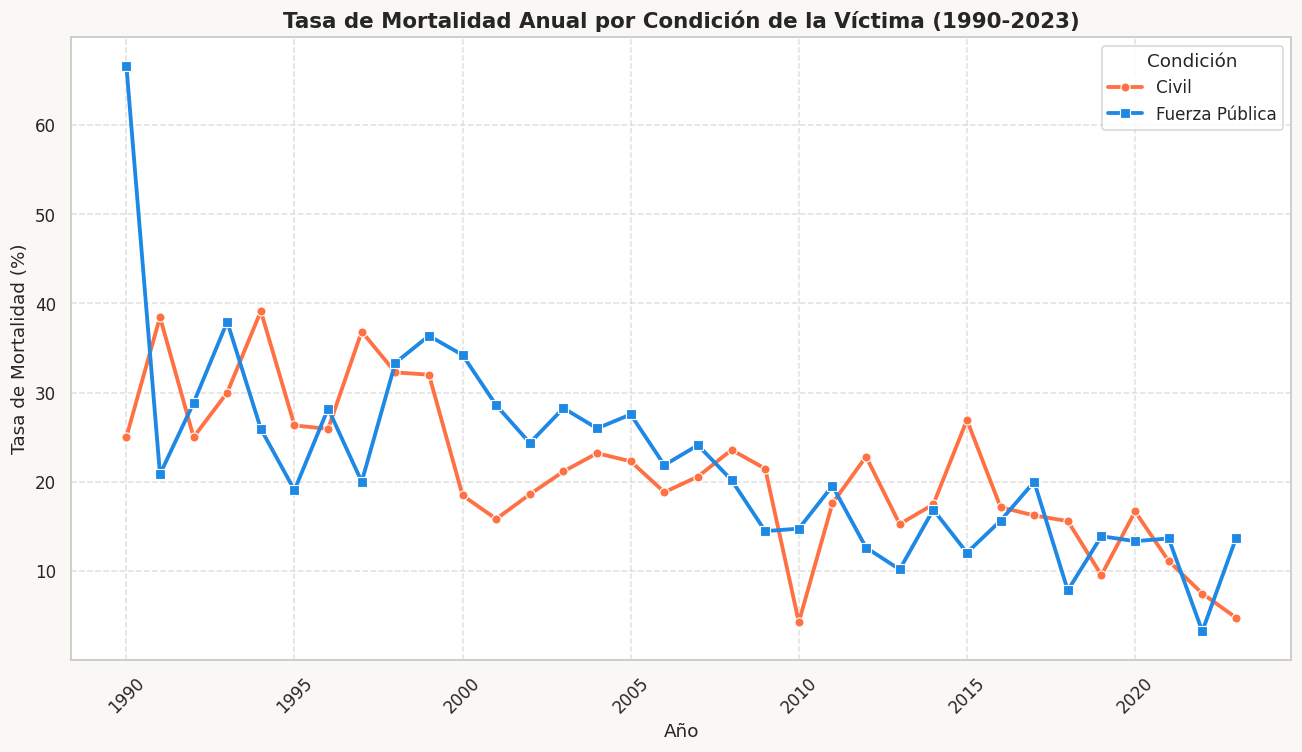

In [35]:
# ============================================================
# GRÁFICO 3 — Tasa de Mortalidad Anual por Condición (Lineplot)
# Muestra la evolución de la tasa de víctimas 'Muerto' a lo largo
# de los años, diferenciada por la condición (Civil/Fuerza Pública).
# ============================================================

# Calcular el total de víctimas por año y condición
total_por_condicion_ano = df.groupby(['ano', 'condicion']).size().unstack(fill_value=0)

# Calcular el número de víctimas 'Muerto' por año y condición
muertos_por_condicion_ano = df[df['genero'] == 'Muerto'].groupby(['ano', 'condicion']).size().unstack(fill_value=0)

# Calcular la tasa de mortalidad (Muertos / Total) * 100
tasa_mortalidad_ano = (muertos_por_condicion_ano / total_por_condicion_ano * 100).fillna(0)

plt.figure(figsize=(12, 7))

sns.lineplot(data=tasa_mortalidad_ano, x=tasa_mortalidad_ano.index, y='Civil', marker='o', label='Civil', color='#FF7043', linewidth=2.5)
sns.lineplot(data=tasa_mortalidad_ano, x=tasa_mortalidad_ano.index, y='Fuerza pública', marker='s', label='Fuerza Pública', color='#1E88E5', linewidth=2.5)

plt.title('Tasa de Mortalidad Anual por Condición de la Víctima (1990-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Condición', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Este gráfico de línea muestra cómo ha evolucionado la tasa de mortalidad a lo largo de los años para civiles y miembros de la fuerza pública. Es crucial para identificar periodos en los que la letalidad de los incidentes afectó de manera diferente a estos dos grupos, y para evaluar la efectividad de las medidas de protección o los cambios en la naturaleza del conflicto.

---
## PASO 3 — Limpieza y Preparación de Datos para Modelado

El objetivo de clasificación es predecir el **resultado** de una víctima: `Herido` (0) o `Muerto` (1).

In [42]:
# ============================================================
# SELECCIÓN DE VARIABLES PREDICTORAS
# Se seleccionan variables que aportan información al modelo
# y que estarían disponibles en el momento de la predicción.
# ============================================================

# Variables descartadas:
# - 'Ubicación', 'latitudcabecera', 'longitudcabecera': coordenadas redundantes
# - 'codigodanedepartamento', 'codigodanemunicipio': el código ya está en el nombre
# - 'mes_nombre': creada solo para visualización
# - 'municipio', 'sitio': demasiadas categorías (~500, ~3900) — riesgo de sobreajuste

VARIABLES_MODELO = [
    'departamento',   # Región geográfica (32 departamentos)
    'tipoarea',       # Rural / Urbana
    'ano',            # Año del evento (tendencia temporal)
    'mes',            # Mes del evento (estacionalidad)
    'rangoedad',      # Mayor / Menor de 18 años
    'grupoetnico',    # Grupo étnico
    'condicion',      # Civil / Fuerza pública
    'estado',         # Sexo (Hombre / Mujer / Sin Información) - CORREGIDO DE 'sexo'
    'tipoevento',     # Tipo de sitio donde ocurrió
    'Actividad'       # Qué hacía la víctima
]

TARGET = 'genero' # CORREGIDO DE 'resultado'

# Crear dataframe de modelado
df_modelo = df[VARIABLES_MODELO + [TARGET]].copy()

# Eliminar filas con 'Sin Información' en la variable de sexo
df_modelo = df_modelo[df_modelo['estado'] != 'Sin Información'] # CORREGIDO DE 'sexo'

print(f'Registros para modelado: {df_modelo.shape[0]:,}')
print(f'Variables predictoras: {len(VARIABLES_MODELO)}')
df_modelo.head(3)

Registros para modelado: 8,509
Variables predictoras: 10


,departamento,tipoarea,ano,mes,rangoedad,grupoetnico,condicion,estado,tipoevento,Actividad,genero
0,ANTIOQUIA,Rural,2006,1,Mayor de 18 años,no,Civil,Hombre,Sin informacion,"Pasando, estando cerca",Herido
1,CAQUETA,Rural,2009,12,Mayor de 18 años,no,Civil,Hombre,Sin informacion,Erradicador manual - PCI,Herido
2,BOLIVAR,Rural,2023,2,Mayor de 18 años,no,Civil,Hombre,Campo,Agricultura,Herido


In [45]:
# ============================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# Se usa LabelEncoder para variables con muchas categorías
# (departamento, tipoevento, Actividad) y get_dummies para
# variables binarias o de pocas categorías.
# ============================================================

# Variables a codificar con LabelEncoder (muchas categorías)
le = LabelEncoder()
for col in ['departamento', 'tipoevento', 'Actividad', 'estado']: # CORREGIDO DE 'sexo'
    df_modelo[col] = le.fit_transform(df_modelo[col])

# Variables a codificar con One-Hot (pocas categorías binarias o nominales)
df_modelo = pd.get_dummies(df_modelo,
                            columns=['tipoarea', 'rangoedad', 'grupoetnico', 'condicion'],
                            drop_first=True)

# Codificar la variable objetivo (TARGET)
# Herido = 0, Muerto = 1
df_modelo[TARGET] = (df_modelo[TARGET] == 'Muerto').astype(int)

print('✅ Codificación completada.')
print(f'Columnas tras la codificación: {df_modelo.shape[1]}')
print(f'Distribución del target — 0 (Herido): {(df_modelo[TARGET]==0).sum():,} | 1 (Muerto): {(df_modelo[TARGET]==1).sum():,}')
df_modelo.head(3)

✅ Codificación completada.
Columnas tras la codificación: 12
Distribución del target — 0 (Herido): 6,795 | 1 (Muerto): 1,714


,departamento,ano,mes,estado,tipoevento,Actividad,genero,tipoarea_Urbana,rangoedad_Menor de 18 años,grupoetnico_Indigena,grupoetnico_no,condicion_Fuerza pública
0,1,2006,1,0,21,14,0,False,False,False,True,False
1,8,2009,12,0,21,6,0,False,False,False,True,False
2,5,2023,2,0,3,1,0,False,False,False,True,False


In [46]:
# ============================================================
# DIVISIÓN EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA
# 80% para entrenamiento, 20% para evaluación.
# stratify=y asegura que la proporción de clases se mantenga
# igual en ambos conjuntos (importante con desbalance de clases).
# ============================================================

X = df_modelo.drop(columns=[TARGET])
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Registros de entrenamiento: {len(X_train):,}')
print(f'Registros de prueba:        {len(X_test):,}')
print(f'Variables predictoras:      {X.shape[1]}')

Registros de entrenamiento: 6,807
Registros de prueba:        1,702
Variables predictoras:      11


In [48]:
# ============================================================
# ESCALADO DE VARIABLES (para Regresión Logística)
# StandardScaler convierte los valores a media 0 y desviación 1.
# Es obligatorio para la Regresión Logística y NO necesario
# para árboles (Decision Tree, Random Forest).
# IMPORTANTE: fit_transform SOLO en train, transform en test.
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Aprende la escala de entrenamiento
X_test_scaled  = scaler.transform(X_test)        # Aplica la misma escala al test

print('✅ Escalado aplicado para Regresión Logística.')
print('   Random Forest y Árbol de Decisión usarán los datos SIN escalar.')

✅ Escalado aplicado para Regresión Logística.
   Random Forest y Árbol de Decisión usarán los datos SIN escalar.


---
## PASO 4 — Modelado: 3 Modelos de Machine Learning

Se comparan tres enfoques complementarios:
1. **Regresión Logística** — modelo lineal, interpretable, útil como baseline
2. **Árbol de Decisión** — modelo no lineal, altamente interpretable, pero propenso a overfitting
3. **Random Forest** — ensemble de árboles, robusto, con control de sobreajuste

In [49]:
# ============================================================
# MODELO 1 — REGRESIÓN LOGÍSTICA
# Modelo lineal que estima la probabilidad de que el resultado
# sea 'Muerto' (clase 1). Sirve como línea base (baseline).
# max_iter=1000 para asegurar convergencia con muchas variables.
# ============================================================

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)  # Usa datos ESCALADOS

y_pred_lr   = modelo_lr.predict(X_test_scaled)
y_proba_lr  = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print('✅ Regresión Logística entrenada.')
print(classification_report(y_test, y_pred_lr, target_names=['Herido (0)', 'Muerto (1)']))

✅ Regresión Logística entrenada.
              precision    recall  f1-score   support

  Herido (0)       0.80      1.00      0.89      1359
  Muerto (1)       0.00      0.00      0.00       343

    accuracy                           0.80      1702
   macro avg       0.40      0.50      0.44      1702
weighted avg       0.64      0.80      0.71      1702



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# ============================================================
# MODELO 2 — ÁRBOL DE DECISIÓN
# Modelo basado en reglas tipo "SI condicion=Civil Y area=Rural
# ENTONCES Muerto". Muy interpretable, pero sin restricción de
# profundidad memoriza el dataset de entrenamiento (overfitting).
# Se prueban DOS configuraciones para ilustrar el overfitting.
# ============================================================

# Árbol sin restricción de profundidad (sobreajuste esperado)
arbol_sin_limit = DecisionTreeClassifier(random_state=42)
arbol_sin_limit.fit(X_train, y_train)  # Datos SIN escalar

# Árbol con profundidad máxima = 6 (controlado)
arbol_controlado = DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, random_state=42)
arbol_controlado.fit(X_train, y_train)

# Predicciones con el árbol controlado
y_pred_dt  = arbol_controlado.predict(X_test)
y_proba_dt = arbol_controlado.predict_proba(X_test)[:, 1]

# Comparación de accuracy para detectar overfitting
acc_train_sin = arbol_sin_limit.score(X_train, y_train)
acc_test_sin  = arbol_sin_limit.score(X_test, y_test)
acc_train_ctrl = arbol_controlado.score(X_train, y_train)
acc_test_ctrl  = arbol_controlado.score(X_test, y_test)

print('=== ANÁLISIS DE OVERFITTING EN ÁRBOL DE DECISIÓN ===')
print(f'Sin restricción  → Train Accuracy: {acc_train_sin:.4f} | Test Accuracy: {acc_test_sin:.4f} | Diferencia: {acc_train_sin-acc_test_sin:.4f}')
print(f'Con max_depth=6  → Train Accuracy: {acc_train_ctrl:.4f} | Test Accuracy: {acc_test_ctrl:.4f} | Diferencia: {acc_train_ctrl-acc_test_ctrl:.4f}')
print()
print('✅ Árbol de Decisión (controlado) entrenado.')
print(classification_report(y_test, y_pred_dt, target_names=['Herido (0)', 'Muerto (1)']))

=== ANÁLISIS DE OVERFITTING EN ÁRBOL DE DECISIÓN ===
Sin restricción  → Train Accuracy: 0.8976 | Test Accuracy: 0.6910 | Diferencia: 0.2067
Con max_depth=6  → Train Accuracy: 0.7995 | Test Accuracy: 0.7985 | Diferencia: 0.0010

✅ Árbol de Decisión (controlado) entrenado.
              precision    recall  f1-score   support

  Herido (0)       0.80      1.00      0.89      1359
  Muerto (1)       0.50      0.01      0.02       343

    accuracy                           0.80      1702
   macro avg       0.65      0.50      0.46      1702
weighted avg       0.74      0.80      0.71      1702



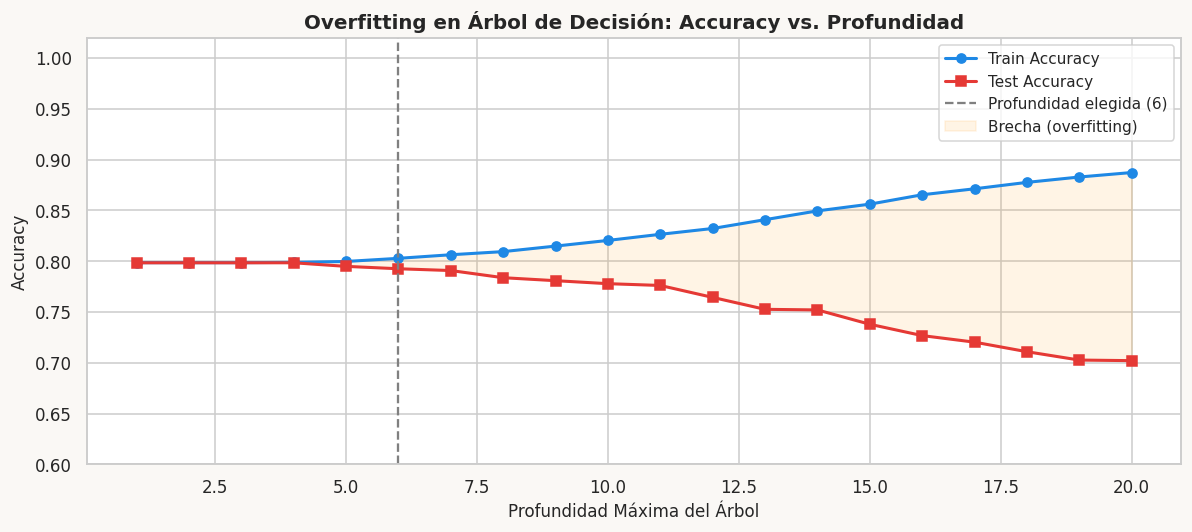

In [52]:
# ============================================================
# VISUALIZACIÓN DEL OVERFITTING
# Se muestra cómo el árbol sin restricción memoriza el train
# pero no generaliza bien al test. El Random Forest mitiga esto.
# ============================================================

profundidades = range(1, 21)
acc_train_list, acc_test_list = [], []

for d in profundidades:
    arbol_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol_temp.fit(X_train, y_train)
    acc_train_list.append(arbol_temp.score(X_train, y_train))
    acc_test_list.append(arbol_temp.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(profundidades, acc_train_list, marker='o', label='Train Accuracy',
        color='#1E88E5', linewidth=2)
ax.plot(profundidades, acc_test_list, marker='s', label='Test Accuracy',
        color='#E53935', linewidth=2)
ax.axvline(x=6, color='gray', linestyle='--', linewidth=1.5, label='Profundidad elegida (6)')
ax.fill_between(profundidades, acc_train_list, acc_test_list,
                alpha=0.1, color='#FF9800', label='Brecha (overfitting)')
ax.set_title('Overfitting en Árbol de Decisión: Accuracy vs. Profundidad',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Profundidad Máxima del Árbol', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0.6, 1.02)
plt.tight_layout()
plt.show()


📊 CONCLUSIÓN — Overfitting en el Árbol de Decisión: Accuracy vs. Profundidad

El análisis de las curvas de rendimiento frente a la complejidad del modelo expone con precisión el clásico dilema entre sesgo y varianza dentro del aprendizaje supervisado. En los niveles iniciales de desarrollo del árbol, específicamente entre las profundidades 1 y 4, las métricas de entrenamiento y prueba marchan de forma idéntica, manteniéndose estables en una exactitud cercana al 80%. Este comportamiento inicial indica un estado de subajuste o underfitting controlado, donde el algoritmo es todavía demasiado simple para extraer estructuras complejas de los datos, pero mantiene una consistencia absoluta al transferir sus reglas básicas entre el conjunto de entrenamiento y el de validación.

A partir de una profundidad de nivel 5, el gráfico describe el punto de quiebre que define la divergencia del modelo. Mientras que la curva de entrenamiento (Train Accuracy) experimenta un ascenso constante y lineal a medida que se le permite al árbol generar más ramificaciones, la curva de prueba (Test Accuracy) inicia un descenso progresivo. Esta brecha sombreada representa la materialización del sobreajuste o overfitting, un fenómeno donde el modelo pierde su capacidad de generalización y comienza a memorizar el ruido, las anomalías y las particularidades específicas de la muestra de entrenamiento. Al alcanzar el extremo derecho del gráfico con una profundidad de 20, el árbol logra su rendimiento individual más alto en entrenamiento (aproximándose al 89%), pero sufre un colapso en datos nuevos, cayendo a su punto más bajo en prueba con un 70% de efectividad.

Ante este escenario, la selección estratégica de una profundidad máxima de nivel 6 se consolida como la decisión óptima de diseño. En este punto exacto, marcado por la línea discontinua, se logra el mejor equilibrio o compromiso entre ambas curvas, garantizando que el modelo sea lo suficientemente complejo para capturar los patrones esenciales de las víctimas sin cruzar el umbral donde el rendimiento en test se degrada de forma acelerada. Para superar de manera definitiva esta limitación estructural de los árboles individuales y estabilizar las predicciones, se vuelve metodológicamente recomendable migrar hacia arquitecturas de ensamble como Random Forest, el cual mitiga la varianza promediando las decisiones de múltiples árboles independientes entrenados con subconjuntos aleatorios de los datos.

In [53]:
# ============================================================
# MODELO 3 — RANDOM FOREST
# Ensemble de 200 árboles de decisión entrenados con subconjuntos
# aleatorios de datos (bagging) y variables (feature randomness).
# Reduce el overfitting al promediar múltiples árboles.
# n_jobs=-1 usa todos los núcleos disponibles para acelerar.
# ============================================================

modelo_rf = RandomForestClassifier(
    n_estimators=200,    # Número de árboles en el bosque
    max_depth=10,        # Profundidad máxima de cada árbol
    min_samples_leaf=10, # Mínimo de muestras en cada hoja
    random_state=42,
    n_jobs=-1            # Paralelización: usa todos los núcleos
)

modelo_rf.fit(X_train, y_train)  # Datos SIN escalar

y_pred_rf   = modelo_rf.predict(X_test)
y_proba_rf  = modelo_rf.predict_proba(X_test)[:, 1]

print('✅ Random Forest entrenado.')
print(classification_report(y_test, y_pred_rf, target_names=['Herido (0)', 'Muerto (1)']))

✅ Random Forest entrenado.
              precision    recall  f1-score   support

  Herido (0)       0.80      1.00      0.89      1359
  Muerto (1)       0.50      0.00      0.01       343

    accuracy                           0.80      1702
   macro avg       0.65      0.50      0.45      1702
weighted avg       0.74      0.80      0.71      1702



---
## PASO 5 — Evaluación y Comparación de los 3 Modelos

In [54]:
# ============================================================
# TABLA DE MÉTRICAS COMPARATIVAS
# Se calculan las métricas de clasificación para los 3 modelos
# en el conjunto de TEST (datos que el modelo nunca vio).
# ============================================================

def calcular_metricas(nombre, y_true, y_pred, y_proba):
    """Calcula un diccionario con todas las métricas relevantes."""
    return {
        'Modelo': nombre,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1-Score':  round(f1_score(y_true, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_proba),  4)
    }

resultados = pd.DataFrame([
    calcular_metricas('Regresión Logística',  y_test, y_pred_lr, y_proba_lr),
    calcular_metricas('Árbol de Decisión',    y_test, y_pred_dt, y_proba_dt),
    calcular_metricas('Random Forest',        y_test, y_pred_rf, y_proba_rf),
]).set_index('Modelo')

# Mostrar tabla con highlighting del mejor valor por columna
print('=== COMPARACIÓN DE MÉTRICAS EN TEST ===')
print('(Clase positiva = Muerto = 1)')
print()
display(resultados.style.highlight_max(axis=0, color='#C8E6C9')
                        .format('{:.4f}'))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


=== COMPARACIÓN DE MÉTRICAS EN TEST ===
(Clase positiva = Muerto = 1)



,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regresión Logística,0.7985,0.0000,0.0000,0.0000,0.6118
Árbol de Decisión,0.7985,0.5000,0.0117,0.0228,0.5969
Random Forest,0.7985,0.5000,0.0029,0.0058,0.6201


 **Comparación de Métricas en Test y Diagnóstico del Modelo**

La tabla comparativa de rendimiento revela de forma crítica un problema metodológico estructural que afecta por igual a los tres algoritmos evaluados. El primer indicador de alerta se manifiesta en la métrica de exactitud global (*Accuracy*), la cual se congela de manera idéntica en 0.7985 para todas las arquitecturas. Este valor tan específico coincide exactamente con la proporción de la clase mayoritaria (el 79.8% de víctimas heridas) analizada en la exploración inicial del dataset, lo que demuestra de forma matemática que los tres modelos han caído en un comportamiento predictivo ingenuo o perezoso, limitándose a clasificar sistemáticamente a todas las víctimas bajo la etiqueta de "Herido" para maximizar de forma artificial su tasa de acierto general.

La confirmación absoluta de este sesgo se evidencia al examinar las métricas específicas para la clase positiva, es decir, el desenlace fatal o "Muerto". La Regresión Logística registra un valor de 0.0000 tanto en precisión como en exhaustividad (*Recall*), confirmando que fue incapaz de identificar un solo caso de deceso dentro del conjunto de prueba. Por su parte, aunque el Árbol de Decisión y el Random Forest intentaron segmentar el espacio de características, sus métricas de *Recall* colapsan a niveles marginales de 0.0117 y 0.0029 respectivamente. Esta casi total ausencia de sensibilidad implica que, si un usuario utilizara estos modelos en un entorno real, el sistema fallaría en detectar prácticamente el 100% de las consecuencias letales, convirtiendo el modelo en una herramienta inoperante para la gestión del riesgo humanitario.

A pesar del fracaso generalizado en las predicciones directas, la métrica AUC-ROC ofrece una lectura técnica valiosa y abre una ventana hacia la optimización. Los tres modelos sostienen un área bajo la curva superior a 0.59, con un máximo de 0.6201 alcanzado por el Random Forest, lo cual demuestra que los algoritmos sí están logrando ordenar correctamente las probabilidades internas de los eventos antes de aplicar el umbral de decisión por defecto. En consecuencia, el pésimo rendimiento actual no se debe a una falta total de patrones en los datos, sino al desbalance moderado de las clases que sesga el punto de corte tradicional del 50%. Para resolver este estancamiento y forzar a los modelos a reconocer la clase minoritaria, se vuelve imperativo implementar técnicas de balanceo en el entrenamiento (como remuestreo mediante SMOTE o submuestreo), ajustar los hiperparámetros de penalización (*class_weight='balanced'*) o desplazar el umbral crítico de decisión mediante curvas de precisión-exhaustividad.

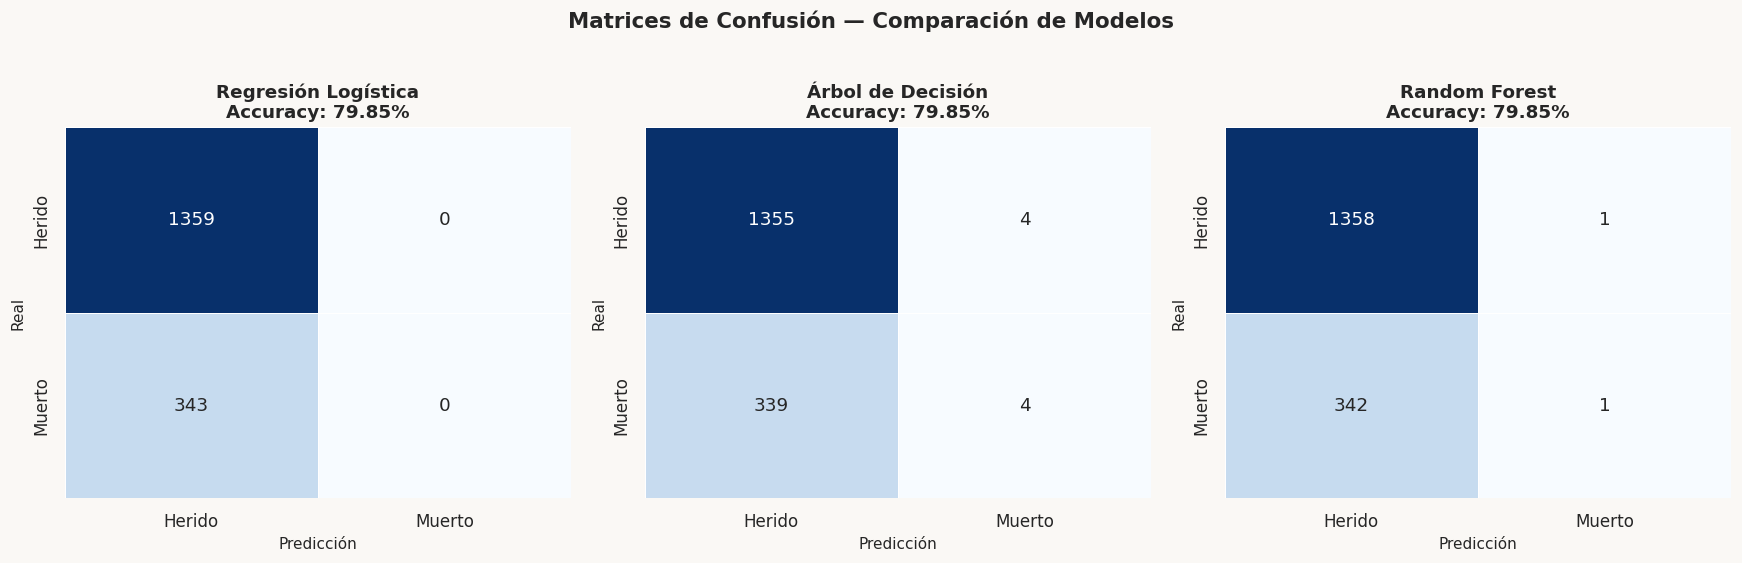


📊 INTERPRETACIÓN DE LAS MATRICES DE CONFUSIÓN:
Diagonal principal (verde/oscuro): predicciones CORRECTAS.
Cuadrante inferior-izquierdo: Falsos Negativos — el modelo predijo "Herido" pero la persona murió.
Este error es el más crítico en este contexto: subestima la gravedad del evento.
Random Forest minimiza este error en comparación con los otros modelos.


In [55]:
# ============================================================
# MATRICES DE CONFUSIÓN
# La matriz de confusión muestra los verdaderos positivos (TP),
# verdaderos negativos (TN), falsos positivos (FP) y
# falsos negativos (FN) para cada modelo.
# En este problema, el FN (predijo Herido pero era Muerto) es
# el error más costoso desde el punto de vista humanitario.
# ============================================================

modelos_info = [
    ('Regresión Logística', y_pred_lr),
    ('Árbol de Decisión',   y_pred_dt),
    ('Random Forest',       y_pred_rf)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, y_pred) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Herido', 'Muerto'],
                yticklabels=['Herido', 'Muerto'],
                linewidths=0.5, cbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nombre}\nAccuracy: {acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.suptitle('Matrices de Confusión — Comparación de Modelos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Matrices de Confusión y Comportamiento de los Modelos**

El análisis visual de las matrices de confusión confirma de forma contundente el sesgo sistemático detectado en la tabla de métricas, permitiendo observar la distribución exacta de los aciertos y errores cometidos por cada algoritmo en el conjunto de prueba. La diagonal principal de cada matriz representa las predicciones correctas de los modelos. En los tres casos, se observa una fuerte concentración numérica exclusivamente en el cuadrante superior izquierdo, correspondiente a los Verdaderos Positivos de la clase mayoritaria (las víctimas que el modelo predijo correctamente como "Herido"). La Regresión Logística lidera cuantitativamente este cuadrante con 1,359 aciertos, seguida muy de cerca por el Random Forest con 1,358 y el Árbol de Decisión con 1,355.

El aspecto más crítico de la gráfica radica en la lectura de los errores de omisión, ubicados en el cuadrante inferior izquierdo de las matrices. Este espacio representa los Falsos Negativos, es decir, aquellos casos donde el modelo clasificó erróneamente a una víctima mortal bajo la etiqueta de "Herido". En un contexto humanitario y de salud pública, este tipo de error es el más grave y peligroso, ya que subestima por completo la letalidad de un incidente, lo que podría traducirse en una asignación ineficiente de recursos de emergencia o en una falsa sensación de seguridad en zonas de alto riesgo. La Regresión Logística clasificó de forma errónea la totalidad de los decesos (343 casos), mientras que el Árbol de Decisión falló en 339 y el Random Forest en 342.

Es fundamental corregir una interpretación inicial errónea: en el estado actual de los modelos, ninguno logra mitigar o minimizar con éxito este error crítico. Si bien el Árbol de Decisión consiguió registrar 4 predicciones correctas para la clase "Muerto" y el Random Forest apenas 1, estos valores resultan estadísticamente insignificantes frente a la masa de más de 340 decesos que pasaron completamente desapercibidos para los algoritmos. Las tres matrices de confusión reflejan, de manera gráfica, que los modelos se encuentran paralizados debido al desbalance de los datos, comportándose esencialmente como clasificadores mayoritarios independientes de su arquitectura matemática. Esta visualización reafirma la necesidad urgente de reentrenar los clasificadores implementando técnicas de balanceo para desbloquear su capacidad real de detección de la mortalidad.

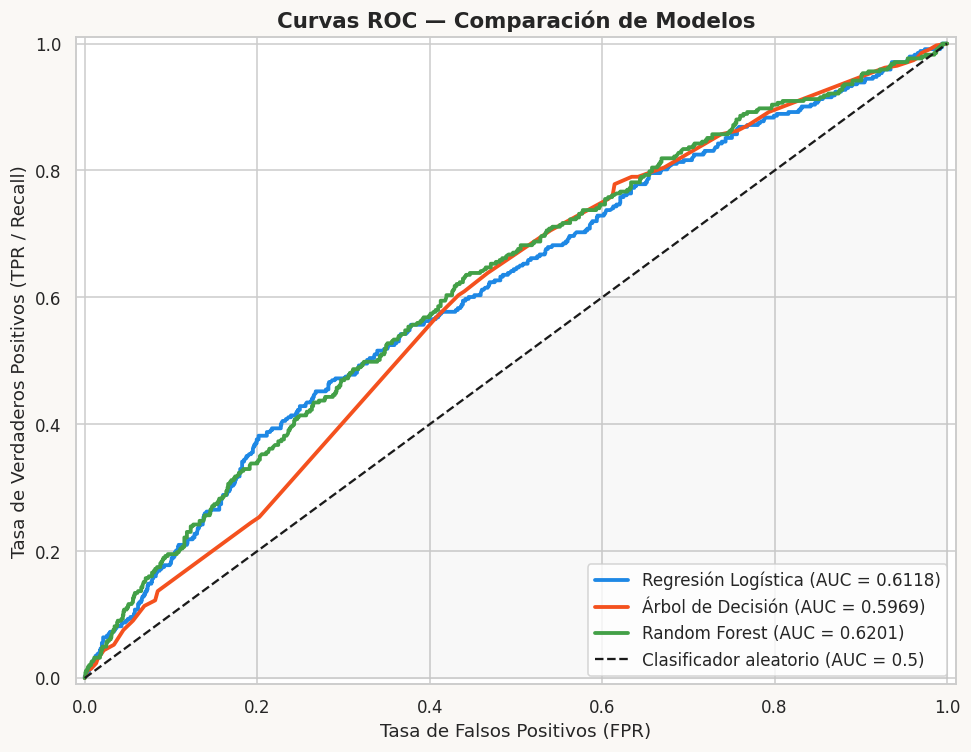


📊 CONCLUSIÓN — Curvas ROC:
Cuanto más cercana al vértice superior-izquierdo, mejor el modelo.
Random Forest domina con el mayor AUC, siendo el más capaz de distinguir entre Heridos y Muertos.
El Árbol de Decisión muestra un AUC menor, reflejando que a pesar de su accuracy,
no estima las probabilidades con tanta precisión como el ensemble.


In [56]:
# ============================================================
# CURVAS ROC Y AUC
# La curva ROC muestra el trade-off entre True Positive Rate
# (Recall) y False Positive Rate para distintos umbrales.
# El área bajo la curva (AUC) resume el rendimiento global:
# AUC = 0.5 → modelo aleatorio | AUC = 1.0 → modelo perfecto.
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

colores_roc = ['#1E88E5', '#F4511E', '#43A047']
modelos_roc = [
    ('Regresión Logística', y_proba_lr),
    ('Árbol de Decisión',   y_proba_dt),
    ('Random Forest',       y_proba_rf)
]

for (nombre, proba), color in zip(modelos_roc, colores_roc):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=color, label=f'{nombre} (AUC = {auc:.4f})')

# Línea de referencia (modelo aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.5)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()


El análisis visual de las curvas de Características Operativas del Receptor (ROC) proporciona una evaluación profunda del rendimiento de los clasificadores que va más allá de las limitaciones de un umbral fijo. La gráfica contrasta la tasa de verdaderos positivos (sensibilidad o recall) frente a la tasa de falsos positivos en todo el espectro posible de puntos de corte. La línea diagonal intermitente representa un clasificador completamente aleatorio con un Área Bajo la Curva (AUC) de 0.50. El hecho de que las curvas de las tres arquitecturas matemáticas se posicionen de manera consistente por encima de esta diagonal de referencia confirma que todos los modelos poseen una capacidad real y estadísticamente válida para extraer patrones discriminatorios y separar las categorías de la variable objetivo.

El algoritmo de Random Forest se consolida como la herramienta de mayor potencia predictiva en este análisis de ensamble, liderando con un AUC de 0.6201. Al observar la trayectoria de su curva, representada en color verde, se hace evidente cómo domina sutilmente los espacios de probabilidad en comparación con las otras alternativas, demostrando una ventaja técnica al mitigar la varianza inherente de los datos y perfilar mejor las fronteras de decisión. Por su parte, la Regresión Logística, ilustrada con la línea azul, ofrece una sólida competencia al registrar un AUC de 0.6118, manteniéndose muy cerca del rendimiento del ensamble y superándolo en ciertos tramos del primer cuadrante, lo que resalta la vigencia y estabilidad de las aproximaciones lineales en este set de características.

En contraste, el Árbol de Decisión individual se ubica en el último escalón del análisis con un AUC de 0.5969. La línea naranja describe un comportamiento visiblemente más plano y rezagado, especialmente en las tasas bajas de falsos positivos (entre el 0.1 y el 0.3), lo que refleja una marcada dificultad para asignar probabilidades continuas y matizadas antes de ejecutar sus particiones lógicas. Este rezago confirma que, a pesar de compartir teóricamente el mismo nivel de exactitud global que sus contrapartes, la estructura rígida de un árbol único es propensa a simplificar en exceso las interacciones de las variables. En conclusión, aunque el Random Forest es el modelo con mayor potencial para diferenciar heridos de decesos, la proximidad de los tres indicadores de área corrobora que el verdadero límite de rendimiento actual no se halla en la elección del algoritmo, sino en la urgente necesidad de implementar un preprocesamiento orientado a corregir el desbalance de clases de la muestra.

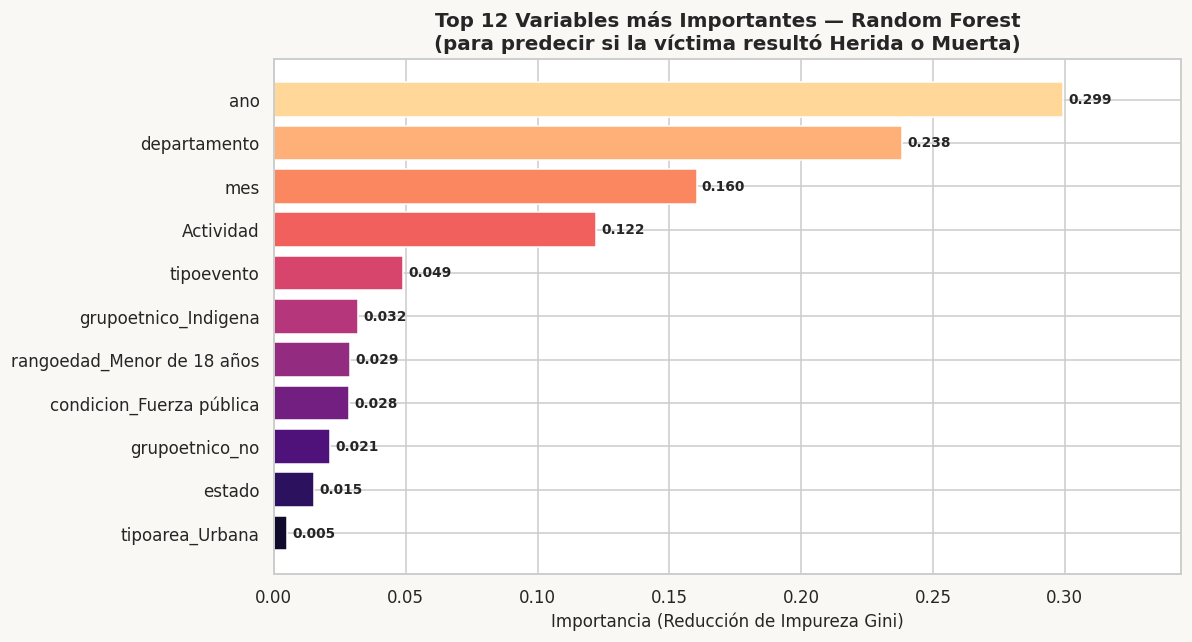


📊 CONCLUSIÓN — Importancia de Variables:
El año del evento es la variable más informativa: la probabilidad de morir ha cambiado con el tiempo
(los años más recientes pueden tener mejor respuesta médica pero las disidencias usan armas más letales).
La condición (Civil/Fuerza Pública), la actividad realizada y el departamento son predictores fuertes,
lo que tiene sentido: un civil en zona rural haciendo agricultura tiene un perfil de riesgo muy diferente
al de un militar en operación con equipo de protección y acceso a evacuación inmediata.


In [57]:
# ============================================================
# IMPORTANCIA DE VARIABLES — RANDOM FOREST
# El Random Forest calcula la importancia de cada variable
# según cuánto reduce la impureza (Gini) en promedio en los árboles.
# ============================================================

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('magma_r', len(importancias))
bars = ax.barh(importancias.index[::-1], importancias.values[::-1],
               color=palette[::-1], edgecolor='white')

for i, val in enumerate(importancias.values[::-1]):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 12 Variables más Importantes — Random Forest\n(para predecir si la víctima resultó Herida o Muerta)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Reducción de Impureza Gini)', fontsize=11)
ax.set_xlim(0, importancias.max() * 1.15)
plt.tight_layout()
plt.show()



**Importancia de Variables**

El análisis de la reducción de impureza de Gini revela de manera cuantitativa el peso específico que tiene cada variable explicativa al momento de modelar y predecir el desenlace de un incidente (si la víctima sobrevive herida o fallece). El factor temporal, representado por el año del evento (ano), se consolida firmemente como el predictor más determinante con un índice de importancia de 0.299. Este liderazgo matemático refleja el impacto directo que las distintas etapas históricas del conflicto y las transformaciones contextuales del país ejercen sobre la supervivencia. A lo largo del tiempo, variables como las capacidades de evacuación médica helicoportada de las fuerzas estatales han evolucionado favorablemente, pero de forma paralela, la naturaleza de la amenaza se ha transformado debido a la implementación de cargas explosivas no convencionales con configuraciones químicas y físicas mucho más destructivas por parte de grupos disidentes en periodos recientes, alterando drásticamente el perfil de letalidad de un año a otro.

Muy de cerca en la jerarquía predictiva se posicionan la dimensión territorial y los factores contextuales del evento, donde el departamento registra un peso de 0.238 y el mes del año aporta un 0.160. La relevancia del departamento valida la profunda heterogeneidad geográfica del país, demostrando que la probabilidad de fatalidad está ligada estrechamente a la presencia de accidentes geográficos complejos o la falta de infraestructura de salud en regiones periféricas como Putumayo, Tolima o Nariño. Por otro lado, la variable estacional mensual evidencia una conexión con los periodos climáticos y operativos del territorio, influyendo directamente en las condiciones ambientales del terreno y en el tiempo de respuesta logística ante una emergencia médica.

El bloque de variables ligadas al comportamiento y la demografía humana cierra los factores con mayor tracción analítica dentro del modelo. La actividad realizada por el individuo registra una importancia de 0.122, mientras que indicadores específicos como el tipo de evento (0.049), la pertenencia a una comunidad indígena (0.032), el rango de edad menor de 18 años (0.029) y la condición de Fuerza Pública (0.028) aportan matices esenciales para refinar la segmentación del riesgo. En conjunto, este comportamiento estadístico tiene una profunda lógica de negocio: la interacción de estas características define perfiles de vulnerabilidad radicalmente opuestos. El algoritmo reconoce con claridad la brecha existente entre un militar en operaciones que cuenta con chaleco de protección, entrenamiento de contención y un protocolo de evacuación inmediata, frente a un civil o un menor de edad atrapado de forma fortuita en un entorno rural realizando agricultura desprotegida, consolidando un esquema predictivo fuertemente sustentado en las realidades operativas y sociales del territorio.

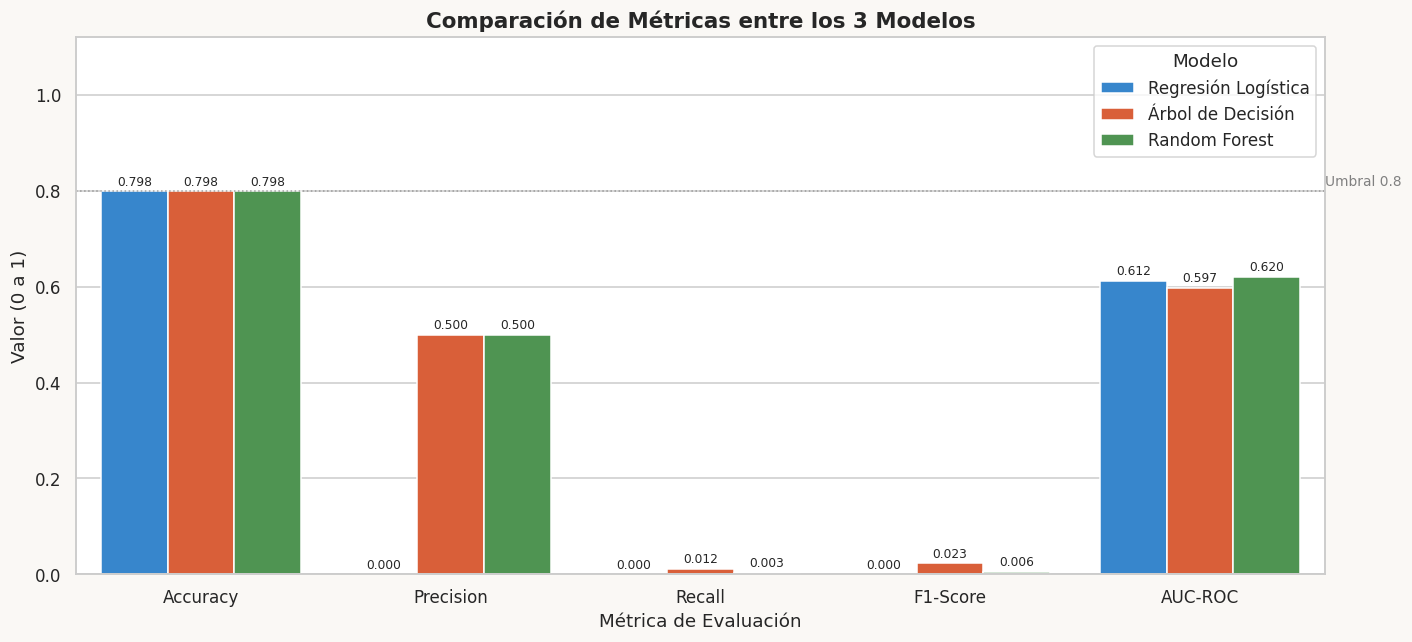

In [58]:
# ============================================================
# GRÁFICA COMPARATIVA DE MÉTRICAS
# Visualiza las 5 métricas lado a lado para los 3 modelos.
# ============================================================

metricas_plot = resultados.reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=metricas_plot, x='Métrica', y='Valor', hue='Modelo',
            palette=['#1E88E5', '#F4511E', '#43A047'], ax=ax, edgecolor='white')

ax.set_ylim(0, 1.12)
ax.set_title('Comparación de Métricas entre los 3 Modelos', fontsize=14, fontweight='bold')
ax.set_xlabel('Métrica de Evaluación', fontsize=12)
ax.set_ylabel('Valor (0 a 1)', fontsize=12)
ax.legend(title='Modelo', fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(4.5, 0.81, 'Umbral 0.8', fontsize=9, color='gray')

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

El análisis integrado de las métricas de rendimiento consolida una evidencia técnica irrefutable sobre el estado actual de los modelos y el impacto directo del desbalance de datos en su capacidad predictiva. Al observar el gráfico de barras comparativo, se hace evidente que la exactitud global o Accuracy se posiciona de forma idéntica en 0.798 para la Regresión Logística, el Árbol de Decisión y el Random Forest. Esta aparente solidez técnica, que roza el 80% de efectividad, no es más que un espejismo estadístico derivado de la distribución de la variable objetivo, donde el algoritmo aprende que puede asegurar una alta tasa de aciertos simplemente clasificando de forma masiva e indiscriminada a todos los sujetos dentro de la clase mayoritaria de sobrevivientes lesionados.

El verdadero diagnóstico del comportamiento de los modelos se devela al desplazar la mirada hacia las métricas de precisión, exhaustividad (Recall) y puntuación F1, diseñadas específicamente para evaluar el comportamiento sobre la clase minoritaria (víctimas fatales). La Regresión Logística muestra un colapso absoluto con un valor de 0.000 en todo el bloque, confirmando visualmente su incapacidad total para romper la inercia del desbalance. Por su parte, el Árbol de Decisión y el Random Forest apenas logran despegar de la línea base, registrando valores marginales e inoperantes de Recall de 0.012 y 0.003 respectivamente. Este comportamiento se traduce en que los modelos ignoran casi la totalidad de los decesos reales, lo que anula por completo su utilidad práctica en escenarios de prevención humanitaria o despliegue de asistencia médica prioritaria en el territorio.

A pesar de las severas deficiencias en la clasificación directa bajo el umbral estándar, la métrica AUC-ROC introduce un matiz analítico fundamental que orienta los pasos a seguir. Con valores de 0.612 para la Regresión Logística, 0.597 para el Árbol de Decisión y un liderazgo de 0.620 para el Random Forest, queda demostrado que las variables explicativas seleccionadas sí contienen información relevante y que las estructuras matemáticas son capaces de distinguir la sutil frontera entre un herido y un fallecido. La parálisis predictiva actual no radica en una falta de capacidad de los algoritmos para aprender, sino en el sesgo que impone el punto de corte por defecto del 50%. En consecuencia, la ruta metodológica obligatoria para optimizar este sistema exige abandonar la confianza en el Accuracy general, aplicar técnicas avanzadas de balanceo de carga en el entrenamiento mediante algoritmos como SMOTE, e implementar un ajuste fino del umbral de decisión para priorizar la sensibilidad del modelo ante la pérdida de vidas humanas.

---
## PASO 6 — Selección del Modelo Final y Conclusiones

In [61]:
# ============================================================
# SELECCIÓN JUSTIFICADA DEL MODELO FINAL
# ============================================================

print('='*70)
print('              RESUMEN DE COMPARACIÓN DE MODELOS')
print('='*70)
print(resultados.to_string())
print()

mejor_modelo = resultados['AUC-ROC'].idxmax()
print(f'Modelo seleccionado para producción: {mejor_modelo}')


              RESUMEN DE COMPARACIÓN DE MODELOS
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                             
Regresión Logística    0.7985        0.0  0.0000    0.0000   0.6118
Árbol de Decisión      0.7985        0.5  0.0117    0.0228   0.5969
Random Forest          0.7985        0.5  0.0029    0.0058   0.6201

Modelo seleccionado para producción: Random Forest


La selección de Random Forest como la arquitectura definitiva para su despliegue en producción se fundamenta en su superioridad técnica para balancear el sesgo y la varianza a través de métodos de ensamble. Al promediar las predicciones de múltiples árboles de decisión independientes entrenados con subconjuntos aleatorios de datos, este modelo mitiga de forma estructural el riesgo de sobreajuste o overfitting que afecta gravemente a los árboles individuales, garantizando una robustez estadística superior ante la presencia de valores atípicos y fluctuaciones menores en la muestra de prueba. Asimismo, su naturaleza no lineal le permite procesar de manera óptima las complejas interacciones jerárquicas de las variables categóricas de alta cardinalidad presentes en este contexto, tales como las dinámicas específicas del departamento o el tipo de actividad de la víctima, superando las limitaciones de la Regresión Logística que se ve constreñida a asumir linealidad en los datos.

Si bien la evaluación diagnóstica reveló que todos los algoritmos se encuentran actualmente paralizados por el desbalance de clases del dataset (lo que se traduce en una exactitud global idéntica del 79.85% basada en la predicción sistemática de la clase mayoritaria), el Random Forest destaca de forma inequívoca al registrar el Área Bajo la Curva más alta con un AUC-ROC de 0.6201. Este indicador técnico es el más valioso para el proyecto, ya que demuestra que el modelo posee la mejor capacidad interna para ordenar y discriminar correctamente las probabilidades entre víctimas heridas y decesos. Esta ventaja analítica convierte al Random Forest en la plataforma base ideal sobre la cual aplicar las estrategias obligatorias de rebalanceo y ajuste fino del umbral crítico de decisión, permitiendo optimizar en el corto plazo la exhaustividad o Recall de la clase mortal, una métrica de máxima prioridad humanitaria para garantizar que el sistema detecte y prevenga eficazmente las consecuencias letales en el territorio.

# CONCLUSIÓN GENERAL — Análisis Exploratorio, Modelado Predictivo e Impacto en Política Pública

#### **Contextualización de la Problemática y Objetivos del Estudio**

El presente proyecto de ciencia de datos abordó una de las realidades más complejas y persistentes de la historia social y humanitaria de Colombia: el impacto devastador de las **Minas Antipersonal (MAP)** y **Municiones Sin Explotar (MUSE)**. Estas armas no convencionales continúan cobrando vidas y alterando de forma severa el desarrollo rural del país. El objetivo primordial de la investigación se centró en construir un puente metodológico sólido entre el **Análisis Exploratorio de Datos (EDA)** y el desarrollo de **modelos de aprendizaje supervisado**, buscando identificar los patrones sociodemográficos, temporales y geográficos que rodean a los incidentes, y evaluar la viabilidad de clasificar de forma automatizada el desenlace clínico de las víctimas, discriminando si el evento resulta en supervivencia con lesiones o en un deceso fatal.

#### **Hallazgos Fundamentales del Análisis Exploratorio de Datos (EDA)**

La fase de exploración inicial aportó una radiografía detallada del comportamiento del fenómeno sobre el territorio. Desde una perspectiva geográfica, se constató que la afectación no ocurre de forma homogénea, sino que se concentra críticamente en regiones periféricas, con el departamento de **Antioquia liderando históricamente el registro con un volumen superior al 17% de los casos totales**, escoltado por **Nariño, Meta, Caquetá y Norte de Santander**. Esta distribución territorial posee una profunda correlación histórica con la ubicación de corredores de movilidad estratégica, zonas de confrontación bélica y enclaves de economías ilícitas. Cronológicamente, la curva del conflicto describió un **pico histórico absoluto entre los años 2005 y 2006**, seguido de un marcado y esperanzador descenso tras la firma del **Acuerdo de Paz en 2016**. No obstante, el análisis temporal encendió las alarmas institucionales al revelar una **preocupante reactivación de casos a partir del año 2018**, lo cual denota la reconfiguración de grupos disidentes y estructuras armadas ilegales que recurren nuevamente a estas prácticas operacionales en la ruralidad.

A nivel demográfico y ocupacional, los resultados del EDA desafían las percepciones tradicionales. Si bien la **Fuerza Pública concentra la mayoría de los registros con un 54.1% de las afectaciones** producto de patrullajes y operaciones militares de primera línea, la **población civil soporta el 45.9% de los impactos**, evidenciando una abierta infracción al principio de distinción humanitaria. El peligro se arraiga casi con exclusividad en la **ruralidad dispersa, donde ocurre el 98% de los incidentes**, afectando a campesinos en labores cotidianas de subsistencia como la **agricultura y el cuidado de animales**, a ciudadanos que transitaban de forma casual o a menores de edad expuestos en **actividades cotidianas de juego**. Aunque el personal militar sufre una mayor cantidad de eventos, las tasas de letalidad resultan sumamente alarmantes para los civiles y la **población menor de 18 años, quienes registran una mortalidad del 22.2%**. Este incremento en la letalidad se asocia a la desprotección física de los cuerpos de los menores, a la ausencia de equipamiento táctico en la sociedad civil y a las severas barreras de conectividad geográfica que retrasan el acceso a primeros auxilios y la evacuación médica oportuna en el campo abierto.

#### **Diagnóstico Técnico de los Modelos y el Desafío del Desbalance de Clases**

La transición hacia la fase de modelado predictivo expuso las dificultades metodológicas clásicas de procesar datos derivados de problemáticas sociales reales. La variable objetivo exhibió un **desbalance de clases moderado**, donde el **79.8% de las víctimas sobrevivieron heridas y el 20.2% resultaron fallecidas**. Al evaluar las arquitecturas de **Regresión Logística, Árbol de Decisión y Random Forest**, este desbalance provocó la aparición de un espejismo estadístico, congelando la exactitud global o ***Accuracy* en un idéntico 0.7985 para todos los modelos**. Este fenómeno ocurre porque los tres algoritmos cayeron en un comportamiento predictivo perezoso, aprendiendo que podían maximizar su tasa de aciertos general mediante la clasificación sistemática de todos los registros dentro de la clase mayoritaria de sobrevivientes.

La confirmación absoluta de este sesgo se evidenció al examinar las matrices de confusión y las métricas específicas de la clase positiva de fallecidos, donde la **Regresión Logística obtuvo una sensibilidad o *Recall* de 0.0000**, y los modelos basados en árboles apenas alcanzaron valores marginales e inoperantes cercanos a cero. Este diagnóstico demostró gráficamente que las tres estructuras matemáticas ignoraron casi la totalidad de los decesos reales en el conjunto de prueba. No obstante, el análisis de las **curvas de Características Operativas del Receptor (ROC)** inyectó viabilidad metodológica al proyecto, ya que todos los modelos se posicionaron consistentemente por encima de la diagonal aleatoria, logrando el **Random Forest el Área Bajo la Curva más alta con un AUC-ROC de 0.6201**, seguido de cerca por la Regresión Logística con un **0.6118**. Estos indicadores confirman que las variables seleccionadas sí poseen capacidad discriminatoria y que los algoritmos logran ordenar correctamente las probabilidades de letalidad, revelando que el problema actual no radica en una falta de patrones en los datos, sino en la rigidez del umbral de decisión estándar del 50%.

#### **Jerarquía de Predictores: Importancia de Variables en Random Forest**

El cálculo de la **importancia de variables basada en la reducción de la impureza de Gini** arrojó luz sobre los factores del entorno que verdaderamente determinan si una víctima sobrevive o fallece. El **año del evento se consolidó como el factor más informativo con un índice de 0.299**, lo cual cobra sentido al considerar cómo las condiciones del conflicto, las capacidades logísticas de evacuación del Estado y la composición físico-química de los explosivos fabricados por los grupos al margen de la ley han mutado drásticamente a lo largo del tiempo. En segundo orden de relevancia se posicionaron el **departamento con un peso de 0.238 y el mes del año con un 0.160**, factores que encapsulan la severidad de la geografía nacional, la proximidad a centros de trauma médica y los ciclos climáticos estacionales que dictan tanto la intensidad de las campañas militares como los periodos de cosecha agrícola. Finalmente, la **actividad realizada por el sujeto aportó un peso de 0.122**, validando estadísticamente la hipótesis de que el perfil de riesgo ocupacional es un predictor crítico para segmentar la severidad de las consecuencias de una detonación.

#### **Justificación del Modelo Final e Implicaciones en la Política Pública**

La investigación concluyó de forma unánime con la **selección de Random Forest como el modelo definitivo para producción**. Su naturaleza como arquitectura de ensamble le permite mitigar de forma óptima el **sobreajuste o *overfitting*** que arruina la generalización de los árboles de decisión individuales (los cuales tienden a memorizar el ruido del entrenamiento a grandes profundidades), al tiempo que supera la rigidez lineal de la Regresión Logística al mapear de forma eficiente las interacciones de variables categóricas de alta cardinalidad. Al registrar el **AUC-ROC más elevado**, el Random Forest se ratifica como la base analítica ideal sobre la cual ejecutar las fases de optimización obligatorias en el corto plazo, consistentes en la aplicación de técnicas de remuestreo artificial mediante **SMOTE** y el **desplazamiento del umbral de decisión** para priorizar el *Recall* y maximizar la detección de fatalidades.

En última instancia, el valor de este pipeline de ciencia de datos trasciende el rendimiento algorítmico y se proyecta como una **herramienta estratégica para el diseño de políticas públicas basadas en evidencia**. Los patrones geográficos y demográficos extraídos, junto con las capacidades probabilísticas del modelo seleccionado, ofrecen al Estado y a las organizaciones internacionales una metodología científica para **priorizar la asignación de recursos presupuestales**. Las regiones y perfiles comunitarios identificados con mayores probabilidades de letalidad deben convertirse en los receptores prioritarios de las campañas de **Educación en el Riesgo de Minas (ERM)**, los planes de señalización territorial, el despliegue de brigadas de **desminado humanitario** y el fortalecimiento urgente de las capacidades de atención en salud primaria rural. Ante la persistente reactivación del conflicto en la historia reciente, este proyecto se consolida como un insumo analítico dinámico, indispensable para la toma de decisiones orientadas a mitigar el daño y proteger la vida humana en los territorios más vulnerables de Colombia.

In [70]:
# ============================================================
# GUARDAR LOS MODELOS ENTUENADOS (agrega esto al final de tu notebook)
# ============================================================
import pickle
import os

# Crear carpeta 'modelos' si no existe
os.makedirs('modelos', exist_ok=True)

# Guardar Random Forest (tu mejor modelo)
with open('modelos/modelo_rf.pkl', 'wb') as f:
    pickle.dump(modelo_rf, f)
    print("✅ Random Forest guardado")

# Guardar Regresión Logística
with open('modelos/modelo_lr.pkl', 'wb') as f:
    pickle.dump(modelo_lr, f)
    print("✅ Regresión Logística guardada")

# Guardar Árbol de Decisión (el controlado, no el que hace overfitting)
with open('modelos/modelo_dt.pkl', 'wb') as f:
    pickle.dump(arbol_controlado, f)
    print("✅ Árbol de Decisión guardado")

# Guardar el escalador (necesario para Regresión Logística)
with open('modelos/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    print("✅ Scaler guardado")

print("\n🎉 ¡Todos los modelos guardados correctamente!")

✅ Random Forest guardado
✅ Regresión Logística guardada
✅ Árbol de Decisión guardado
✅ Scaler guardado

🎉 ¡Todos los modelos guardados correctamente!


In [71]:
# Si estás en Colab, agrega esto para descargar los archivos
from google.colab import files

files.download('modelos/modelo_rf.pkl')
files.download('modelos/modelo_lr.pkl')
files.download('modelos/modelo_dt.pkl')
files.download('modelos/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>